# Projeto: Previsão de Resultados de Futebol - Liga Portuguesa
## Parte 1: Redes Bayesianas

### 0. Bibliotecas

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, HillClimbSearch
from pgmpy.inference import VariableElimination
import networkx as nx
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from crepes import WrapClassifier
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, log_loss

### 1. Configuração do Ambiente e Carregamento de Dados

In [48]:
df = pd.read_csv('dataset.csv')

cols = ['ht_form', 'at_form', 'ht_attack', 'at_attack', 'h2h_dominance', 'odds_favorite', 'result']
data = df[cols].copy()

data.head()

,ht_form,at_form,ht_attack,at_attack,h2h_dominance,odds_favorite,result
0,good,below avg,average,average,balanced,home,A
1,average,average,average,weak,balanced,home,D
2,average,average,average,average,balanced,home,D
3,poor,poor,weak,weak,balanced,home,H
4,poor,good,weak,above avg,balanced,balanced,H


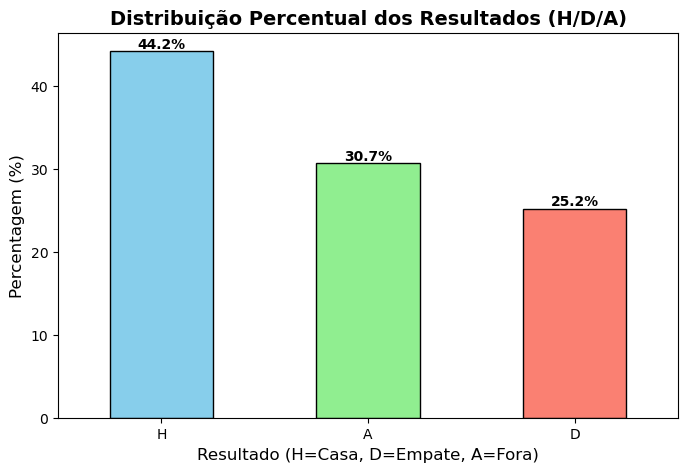

In [49]:
percentagens = data['result'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
ax = percentagens.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'], edgecolor='black')

plt.title('Distribuição Percentual dos Resultados (H/D/A)', fontsize=14, fontweight='bold')
plt.xlabel('Resultado (H=Casa, D=Empate, A=Fora)', fontsize=12)
plt.ylabel('Percentagem (%)', fontsize=12)
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.show()

### 2. Construção da Estrutura da Rede Bayesiana

Nesta secção, avaliamos duas estratégias:
1. **Knowledge Engineering**: Estrutura manual baseada no conhecimento do domínio.
2. **Aprendizagem Automática**: Estrutura aprendida a partir dos dados.

#### 2.1. Estrutura Manual (Knowledge Engineering)
Definimos uma estrutura onde a forma e o ataque de ambas as equipas, juntamente com o histórico (H2H) e as odds, influenciam o resultado final.

In [50]:
ligacoes = [
    # O ataque e os golos marcados geram pontos (forma)
    ('ht_attack', 'ht_form'),
    ('at_attack', 'at_form'),
    
    # A forma (pontos ganhos) e o histórico afetam as odds (as casas de apostas olham muito para os pontos)
    ('ht_form', 'odds_favorite'),
    ('at_form', 'odds_favorite'),
    ('h2h_dominance', 'odds_favorite'),
    
    # A capacidade de ataque e o histórico influenciam o resultado do jogo de hoje
    ('ht_attack', 'result'),
    ('at_attack', 'result'),
    ('h2h_dominance', 'result'),
    
    # As odds captam informação latente (ex: lesões, castigos) que também afeta o resultado
    ('odds_favorite', 'result')
]

manual_model = DiscreteBayesianNetwork(ligacoes)

print("Nós:", manual_model.nodes())
print("Arestas:", manual_model.edges())

Nós: ['ht_attack', 'ht_form', 'at_attack', 'at_form', 'odds_favorite', 'h2h_dominance', 'result']
Arestas: [('ht_attack', 'ht_form'), ('ht_attack', 'result'), ('ht_form', 'odds_favorite'), ('at_attack', 'at_form'), ('at_attack', 'result'), ('at_form', 'odds_favorite'), ('odds_favorite', 'result'), ('h2h_dominance', 'odds_favorite'), ('h2h_dominance', 'result')]


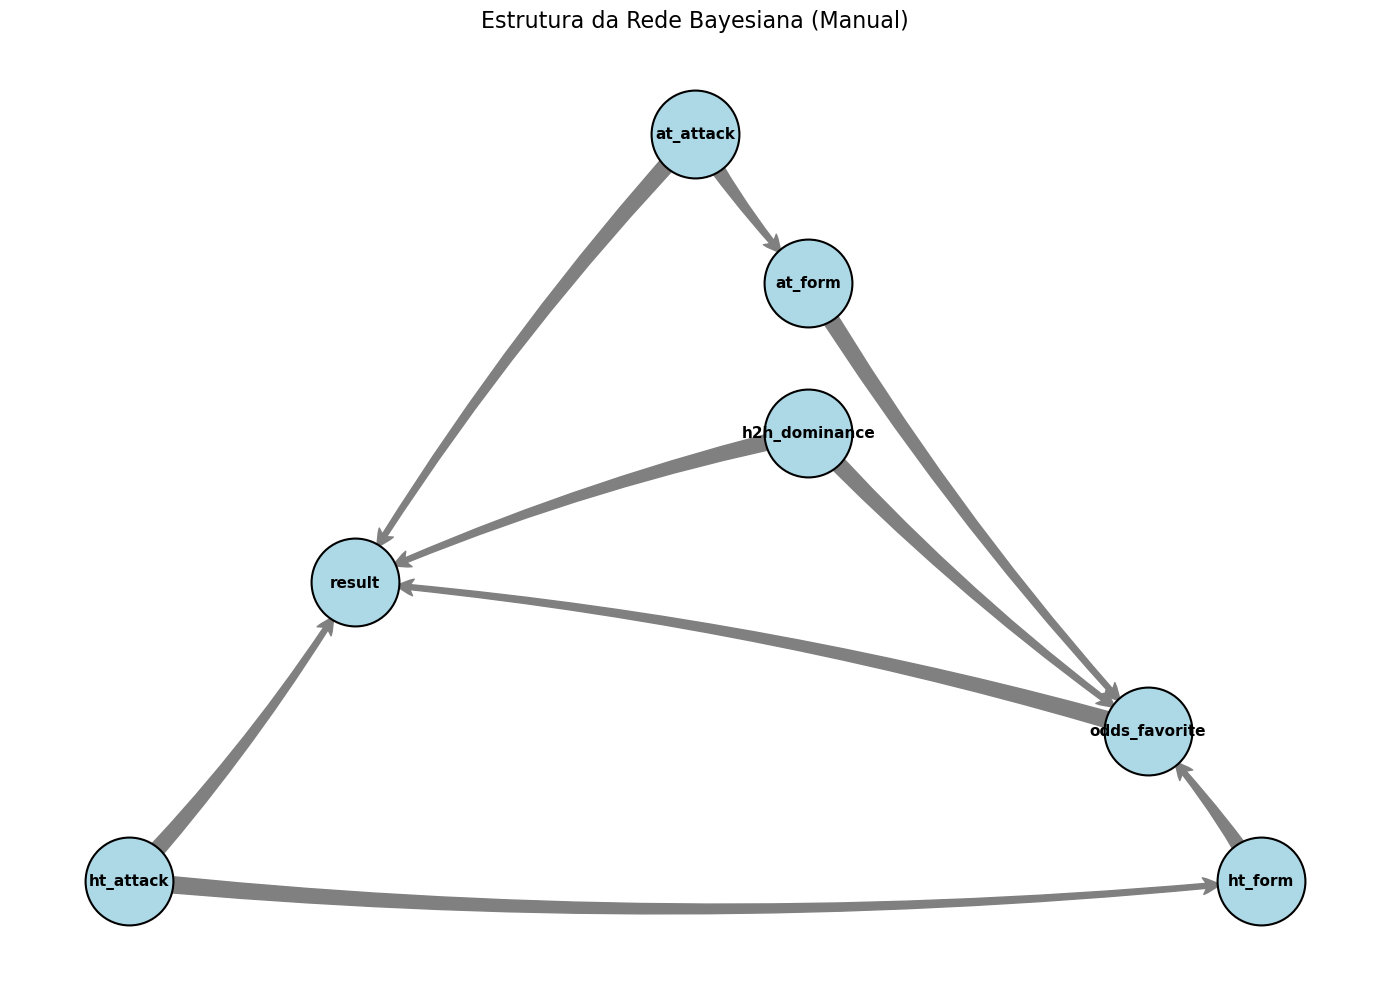

In [51]:
arestas = manual_model.edges() 
filename = 'dag_manual.png' 
G = nx.DiGraph(arestas)

plt.figure(figsize=(14, 10))

try:
    pos = nx.planar_layout(G)
except nx.NetworkXException:
    pos = nx.shell_layout(G)


nx.draw_networkx_nodes(G, pos, 
                       node_size=4000,          
                       node_color='#add8e6',   
                       edgecolors='black',     
                       linewidths=1.5)         


nx.draw_networkx_labels(G, pos, 
                        font_size=11,           
                        font_family='sans-serif',
                        font_weight='bold')     


nx.draw_networkx_edges(G, pos, 
                       edgelist=G.edges(),
                       width=1.0,              
                       edge_color='grey',      
                       arrowstyle='fancy', 
                       arrowsize=30,           
                       connectionstyle='arc3,rad=0.05', 
                       min_target_margin=30)   

# 5. Estética Final e Guardar
plt.title(f"Estrutura da Rede Bayesiana ({filename.split('_')[1].split('.')[0].capitalize()})", fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()

plt.show()

#### 2.2. Aprendizagem Automática de Estrutura
Utilizamos o algoritmo Hill Climb Search com a métrica BIC (Bayesian Information Criterion) para encontrar a melhor estrutura de rede baseada nos dados.

In [52]:
hc = HillClimbSearch(data)
best_model_structure = hc.estimate(scoring_method="bic-d")
auto_model = DiscreteBayesianNetwork(best_model_structure.edges())

print("Arestas aprendidas:", auto_model.edges())

/var/folders/j1/vm53k26x2qbc0hxh9tp8sd3h0000gn/T/ipykernel_66066/2620387882.py:1: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(data)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Arestas aprendidas: [('ht_form', 'h2h_dominance'), ('ht_form', 'odds_favorite'), ('h2h_dominance', 'odds_favorite'), ('h2h_dominance', 'result'), ('h2h_dominance', 'at_attack'), ('odds_favorite', 'at_attack'), ('odds_favorite', 'result'), ('odds_favorite', 'at_form'), ('ht_attack', 'ht_form'), ('at_attack', 'at_form')]


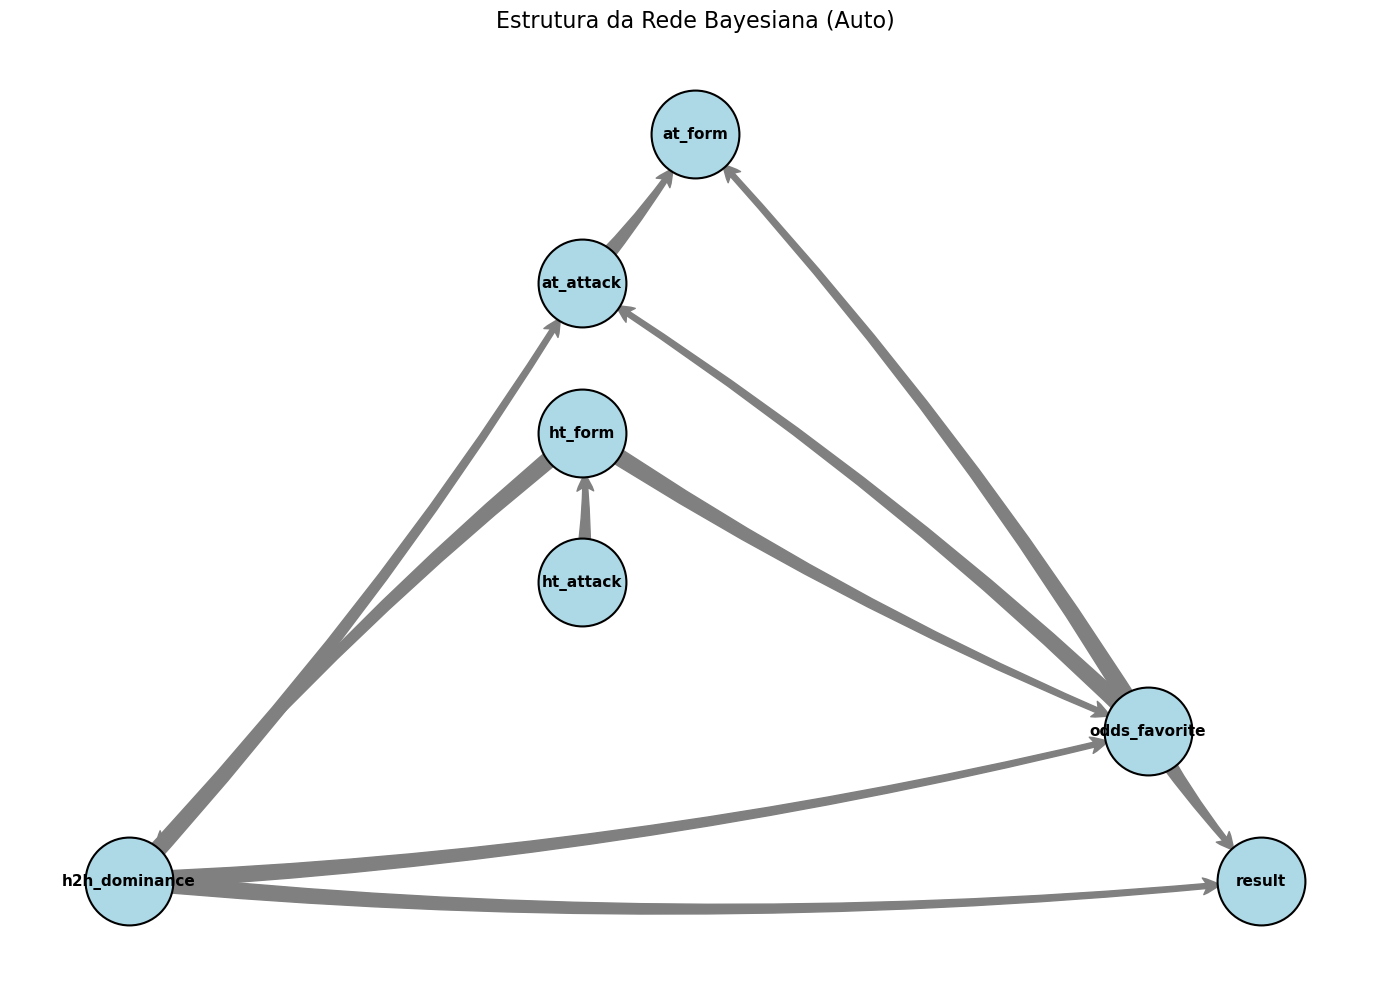

In [53]:
arestas = auto_model.edges() 
filename = 'dag_auto.png'
G = nx.DiGraph(arestas)

plt.figure(figsize=(14, 10)) 

try:
    pos = nx.planar_layout(G)
except nx.NetworkXException:
    pos = nx.shell_layout(G)


nx.draw_networkx_nodes(G, pos, 
                       node_size=4000,          
                       node_color='#add8e6',   
                       edgecolors='black',     
                       linewidths=1.5)         


nx.draw_networkx_labels(G, pos, 
                        font_size=11,           
                        font_family='sans-serif',
                        font_weight='bold')     

nx.draw_networkx_edges(G, pos, 
                       edgelist=G.edges(),
                       width=1.0,              
                       edge_color='grey',      
                       arrowstyle='fancy', 
                       arrowsize=30,           
                       connectionstyle='arc3,rad=0.05', 
                       min_target_margin=30)   

plt.title(f"Estrutura da Rede Bayesiana ({filename.split('_')[1].split('.')[0].capitalize()})", fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()

plt.show()

### 3. Análise da Rede Bayesiana utilizando D-separação

A D-separação permite identificar independências condicionais na rede.

In [54]:
print("Independências Locais (Manual Model - result):")
print(manual_model.local_independencies('result'))

print("\nIndependências Globais (Auto Model - subset):")
all_independencies = auto_model.get_independencies()
print(list(all_independencies.independencies)[:]) 

Independências Locais (Manual Model - result):
(result ⟂ at_form, ht_form | at_attack, h2h_dominance, ht_attack, odds_favorite)

Independências Globais (Auto Model - subset):
[(at_form ⟂ result | h2h_dominance, odds_favorite), (at_attack ⟂ result | h2h_dominance, odds_favorite), (ht_attack ⟂ result | h2h_dominance, odds_favorite), (at_form ⟂ h2h_dominance | at_attack, odds_favorite), (at_attack ⟂ ht_form | h2h_dominance, odds_favorite), (at_attack ⟂ ht_attack | h2h_dominance, odds_favorite), (ht_attack ⟂ odds_favorite | ht_form), (ht_form ⟂ result | h2h_dominance, odds_favorite), (at_form ⟂ ht_form | at_attack, odds_favorite), (h2h_dominance ⟂ ht_attack | ht_form), (at_form ⟂ ht_attack | at_attack, odds_favorite)]


In [55]:
def testar_d_separacao(modelo, origem, destino, observados=[]):
    """
    Verifica se a informação flui da origem para o destino.
    Retorna True se estiverem DEPENDENTES (Caminho Ativo).
    Retorna False se estiverem INDEPENDENTES (D-Separados).
    """
    # Descobre todos os nós alcançáveis a partir da 'origem'
    alcançaveis = modelo.active_trail_nodes(origem, observed=observados)[origem]
    
    # Verifica se o 'destino' está na lista de alcançáveis
    caminho_ativo = destino in alcançaveis
    
    obs_str = f" (Observando: {observados})" if observados else " (Nenhuma observação)"
    status = "ATIVO (Dependentes)" if caminho_ativo else "BLOQUEADO (D-Separados)"
    
    print(f"Caminho {origem} <-> {destino}{obs_str}: {status}")
    return caminho_ativo

In [56]:
print("--- TESTES DE D-SEPARAÇÃO (MANUAL MODEL) ---\n")

# ---------------------------------------------------------
# EXEMPLO 1: ESTRUTURA EM V (Colisor)
# Caminho: ht_attack -> result <- at_attack
# Regra: Inativo por defeito. Fica ativo se o colisor ('result') for observado.
# ---------------------------------------------------------
print("EXEMPLO 1: Estrutura em V (Explaining Away)")
testar_d_separacao(manual_model, 'ht_attack', 'at_attack', observados=[])
testar_d_separacao(manual_model, 'ht_attack', 'at_attack', observados=['result'])


# ---------------------------------------------------------
# EXEMPLO 2: CASCATA (Chain)
# Caminho: ht_attack -> ht_form -> odds_favorite
# Regra: Ativo por defeito. Fica bloqueado se o nó intermédio ('ht_form') for observado.
# ---------------------------------------------------------
print("\nEXEMPLO 2: Cascata")
testar_d_separacao(manual_model, 'ht_attack', 'odds_favorite', observados=[])
testar_d_separacao(manual_model, 'ht_attack', 'odds_favorite', observados=['ht_form'])


--- TESTES DE D-SEPARAÇÃO (MANUAL MODEL) ---

EXEMPLO 1: Estrutura em V (Explaining Away)
Caminho ht_attack <-> at_attack (Nenhuma observação): BLOQUEADO (D-Separados)
Caminho ht_attack <-> at_attack (Observando: ['result']): ATIVO (Dependentes)

EXEMPLO 2: Cascata
Caminho ht_attack <-> odds_favorite (Nenhuma observação): ATIVO (Dependentes)
Caminho ht_attack <-> odds_favorite (Observando: ['ht_form']): BLOQUEADO (D-Separados)


False

In [57]:
print("--- TESTES DE D-SEPARAÇÃO (AUTO MODEL) ---\n")

# ---------------------------------------------------------
# EXEMPLO 1: ESTRUTURA EM FORQUILHA (Common Cause)
# Caminho: at_attack <- odds_favorite -> result
# No auto_model, as odds tornam-se um pai comum (hub).
# ---------------------------------------------------------
print("EXEMPLO 1: Forquilha (Odds como Hub Informativo)")
# Sem observar as odds, a informação flui (são dependentes)
testar_d_separacao(auto_model, 'at_attack', 'result', observados=[])
# Ao observar as odds, o caminho fica bloqueado (d-separados)
testar_d_separacao(auto_model, 'at_attack', 'result', observados=['odds_favorite', 'h2h_dominance'])


# ---------------------------------------------------------
# EXEMPLO 2: CASCATA (Chain) - Inversão Causal
# Caminho: ht_attack -> ht_form -> h2h_dominance
# O algoritmo inverteu a lógica manual h2h -> result[cite: 43].
# ---------------------------------------------------------
print("\nEXEMPLO 2: Cascata (Atalho Estatístico)")
# Sem observações, ht_attack influencia h2h_dominance através da forma
testar_d_separacao(auto_model, 'ht_attack', 'h2h_dominance', observados=[])
# Observar a forma intermédia bloqueia a propagação
testar_d_separacao(auto_model, 'ht_attack', 'h2h_dominance', observados=['ht_form'])

--- TESTES DE D-SEPARAÇÃO (AUTO MODEL) ---

EXEMPLO 1: Forquilha (Odds como Hub Informativo)
Caminho at_attack <-> result (Nenhuma observação): ATIVO (Dependentes)
Caminho at_attack <-> result (Observando: ['odds_favorite', 'h2h_dominance']): BLOQUEADO (D-Separados)

EXEMPLO 2: Cascata (Atalho Estatístico)
Caminho ht_attack <-> h2h_dominance (Nenhuma observação): ATIVO (Dependentes)
Caminho ht_attack <-> h2h_dominance (Observando: ['ht_form']): BLOQUEADO (D-Separados)


False

### 4. Aprendizagem de Parâmetros

Comparamos duas abordagens para estimar as CPTs:
1. **Maximum Likelihood Estimation (MLE)**
2. **Bayesian Estimation**

In [58]:
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator

print("="*50)
print("1. ABORDAGEM MAXIMUM LIKELIHOOD ESTIMATION (MLE)")
print("="*50)

manual_model.fit(data, estimator=MaximumLikelihoodEstimator)

CPDs_mle = manual_model.get_cpds()
for cpd in CPDs_mle:
    print(f"--- Variável: {cpd.variable} ---")
    try:
        print(cpd.to_dataframe()) 
    except ValueError:
        print(cpd)
    print('\n')

1. ABORDAGEM MAXIMUM LIKELIHOOD ESTIMATION (MLE)
--- Variável: ht_attack ---
+----------------------+----------+
| ht_attack(above avg) | 0.185026 |
+----------------------+----------+
| ht_attack(average)   | 0.501343 |
+----------------------+----------+
| ht_attack(strong)    | 0.110335 |
+----------------------+----------+
| ht_attack(weak)      | 0.203296 |
+----------------------+----------+


--- Variável: ht_form ---
ht_form     average  below avg  excellent      good      poor
ht_attack                                                    
above avg  0.396902   0.152953   0.131655  0.303001  0.015489
average    0.339764   0.426224   0.008932  0.080743  0.144337
strong     0.102273   0.009740   0.500000  0.386364  0.001623
weak       0.067841   0.425551   0.000000  0.001762  0.504846


--- Variável: at_attack ---
+----------------------+----------+
| at_attack(above avg) | 0.192549 |
+----------------------+----------+
| at_attack(average)   | 0.505105 |
+----------------------+-

In [59]:
print("2. ABORDAGEM ESTIMAÇÃO BAYESIANA (BDeu)")
manual_model.fit(data, estimator=BayesianEstimator, prior_type="BDeu", equivalent_sample_size=10)

CPDs_bayes = manual_model.get_cpds()
for cpd in CPDs_bayes:
    print(f"--- Variável: {cpd.variable} ---")
    try:
        print(cpd.to_dataframe())
    except ValueError:
        print(cpd)
    print('\n')

2. ABORDAGEM ESTIMAÇÃO BAYESIANA (BDeu)
--- Variável: ht_attack ---
+----------------------+----------+
| ht_attack(above avg) | 0.185142 |
+----------------------+----------+
| ht_attack(average)   | 0.500894 |
+----------------------+----------+
| ht_attack(strong)    | 0.110585 |
+----------------------+----------+
| ht_attack(weak)      | 0.203379 |
+----------------------+----------+


--- Variável: ht_form ---
ht_form     average  below avg  excellent      good      poor
ht_attack                                                    
above avg  0.396427   0.153066   0.131820  0.302752  0.015934
average    0.339639   0.426022   0.009102  0.080850  0.144387
strong     0.102668   0.010509   0.498787  0.385610  0.002425
weak       0.068132   0.425055   0.000440  0.002198  0.504176


--- Variável: at_attack ---
+----------------------+----------+
| at_attack(above avg) | 0.192652 |
+----------------------+----------+
| at_attack(average)   | 0.504649 |
+----------------------+----------

### 5. Inferência Probabilística

Demonstração da utilização da rede para prever resultados com base em diferentes cenários.

In [60]:
print("=== CATEGORIAS DE CADA ATRIBUTO ===\n")

for coluna in data.columns:
    opcoes = data[coluna].unique().tolist()
    
    print(f"Variável: {coluna}")
    print(f"Opções disponíveis: {opcoes}")
    print("-" * 40)

=== CATEGORIAS DE CADA ATRIBUTO ===

Variável: ht_form
Opções disponíveis: ['good', 'average', 'poor', 'excellent', 'below avg']
----------------------------------------
Variável: at_form
Opções disponíveis: ['below avg', 'average', 'poor', 'good', 'excellent']
----------------------------------------
Variável: ht_attack
Opções disponíveis: ['average', 'weak', 'above avg', 'strong']
----------------------------------------
Variável: at_attack
Opções disponíveis: ['average', 'weak', 'above avg', 'strong']
----------------------------------------
Variável: h2h_dominance
Opções disponíveis: ['balanced', 'away_dominant', 'home_dominant']
----------------------------------------
Variável: odds_favorite
Opções disponíveis: ['home', 'balanced', 'away']
----------------------------------------
Variável: result
Opções disponíveis: ['A', 'D', 'H']
----------------------------------------


In [61]:
from pgmpy.inference import VariableElimination

manual_model.fit(data, estimator=BayesianEstimator, prior_type="BDeu", equivalent_sample_size=10)
infer = VariableElimination(manual_model)

print("="*60)
print("INFERÊNCIAS PROBABILÍSTICAS (PARTE 1 - PASSO 4)")
print("="*60)

# ---------------------------------------------------------
# 1. PREVISÃO CLÁSSICA (Causa -> Efeito)
# "O Cenário Perfeito para a Casa"
# ---------------------------------------------------------
print("\n1. Qual a probabilidade de vitória (H/D/A) se a equipa da casa tiver")
print("forma 'excellent', ataque 'strong' e domínio no histórico ('home_dominant')?")
q1 = infer.query(variables=['result'], 
                 evidence={'ht_form': 'excellent', 'ht_attack': 'strong', 'h2h_dominance': 'home_dominant'})
print(q1)

# ---------------------------------------------------------
# 2. INFERÊNCIA DIAGNÓSTICA (Efeito -> Causa)
# "A Anatomia de uma Surpresa"
# ---------------------------------------------------------
print("\n2. A equipa da casa estava em forma 'poor', mas GANHOU ('H').")
print("Qual era a probabilidade de a equipa de fora também estar em má forma ('poor' ou 'below avg')?")
q2 = infer.query(variables=['at_form'], 
                 evidence={'result': 'H', 'ht_form': 'poor'})
print(q2)

# ---------------------------------------------------------
# 3. PREVER O COMPORTAMENTO DAS CASAS DE APOSTAS
# ---------------------------------------------------------
print("\n3. Se o jogo for muito equilibrado ('balanced' no histórico, ataques 'average'),")
print("para onde pendem as casas de apostas (odds_favorite)?")
q3 = infer.query(variables=['odds_favorite'], 
                 evidence={'h2h_dominance': 'balanced', 'ht_attack': 'average', 'at_attack': 'average'})
print(q3)

# ---------------------------------------------------------
# 4. EXPLAINING AWAY (Na Prática!)
# "O Efeito de um Empate"
# ---------------------------------------------------------
print("\n4. A equipa da casa tem um ataque 'strong'.")
print("Sem saber o resultado, como prevemos o ataque de fora?")
q4a = infer.query(variables=['at_attack'], evidence={'ht_attack': 'strong'})
print(q4a)

print("Mas e se soubermos que o jogo acabou empatado ('D')?")
print("Como isso altera a nossa perceção do ataque da equipa de fora?")
q4b = infer.query(variables=['at_attack'], evidence={'ht_attack': 'strong', 'result': 'D'})
print(q4b)

# ---------------------------------------------------------
# 5. O PESO DO HISTÓRICO (H2H)
# ---------------------------------------------------------
print("\n5. As odds dão favoritismo à equipa de FORA ('away').")
print("Sabendo isto, qual a probabilidade de o histórico ser dominado pela equipa da CASA ('home_dominant')?")
print("(Ou seja, as casas de apostas estão a ignorar o histórico?)")
q5 = infer.query(variables=['h2h_dominance'], 
                 evidence={'odds_favorite': 'away'})
print(q5)

INFERÊNCIAS PROBABILÍSTICAS (PARTE 1 - PASSO 4)

1. Qual a probabilidade de vitória (H/D/A) se a equipa da casa tiver
forma 'excellent', ataque 'strong' e domínio no histórico ('home_dominant')?
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.0720 |
+-----------+---------------+
| result(D) |        0.1430 |
+-----------+---------------+
| result(H) |        0.7850 |
+-----------+---------------+

2. A equipa da casa estava em forma 'poor', mas GANHOU ('H').
Qual era a probabilidade de a equipa de fora também estar em má forma ('poor' ou 'below avg')?
+--------------------+----------------+
| at_form            |   phi(at_form) |
+====================+================+
| at_form(average)   |         0.2711 |
+--------------------+----------------+
| at_form(below avg) |         0.3492 |
+--------------------+----------------+
| at_form(excellent) |         0.0609 |
+--------------------+----------------+
| at_form(good)  

# Parte 2: Classificação Probabilística e Quantificação de Incerteza

### 1. Treino e Avaliação do Classificador Naive Bayes

Preparamos os dados (codificação de variáveis categóricas) e treinamos um modelo Naive Bayes para prever o resultado (H/D/A).

In [62]:
# 1. Primeiro, removemos as variáveis proibidas (Data Leakage e Identificadores)
colunas_proibidas = ['date', 'ht', 'at', 'hg', 'ag']
df_limpo = df.drop(columns=colunas_proibidas, errors='ignore')

y = df_limpo['result']
X_completo = df_limpo.drop(columns=['result'])

X_cont = X_completo.select_dtypes(include=[np.number])

X_disc = X_completo.select_dtypes(exclude=[np.number])

print(f"Encontradas {X_cont.shape[1]} Variáveis Contínuas:")
print(X_cont.columns.tolist())

print(f"\nEncontradas {X_disc.shape[1]} Variáveis Discretas:")
print(X_disc.columns.tolist())

Encontradas 18 Variáveis Contínuas:
['h_odds', 'd_odds', 'a_odds', 'ht_form_points', 'ht_form_goals_scored', 'ht_form_goals_conceded', 'ht_form_wins', 'at_form_points', 'at_form_goals_scored', 'at_form_goals_conceded', 'at_form_wins', 'ht_home_form_points', 'ht_home_form_goals_scored', 'at_away_form_points', 'at_away_form_goals_scored', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins']

Encontradas 7 Variáveis Discretas:
['ht_form', 'at_form', 'ht_attack', 'at_attack', 'joint_attack', 'h2h_dominance', 'odds_favorite']


In [63]:

X_temp, X_test, y_temp, y_test = train_test_split(X_cont, y, test_size=0.2, random_state=42)
X_train, X_cal, y_train, y_cal = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

scaler = StandardScaler() 

X_train_scaled = scaler.fit_transform(X_train) 

X_cal_scaled = scaler.transform(X_cal) 
X_test_scaled = scaler.transform(X_test) 

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42)
}


for name, model in classifiers.items():
    print(f"\n[{name.upper()}]")
    print("-" * 50)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Log Loss: {log_loss(y_test, y_prob):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("=" * 50)


[LOGISTIC REGRESSION]
--------------------------------------------------
Accuracy: 0.5336
Log Loss: 0.9546

Classification Report:
              precision    recall  f1-score   support

           A       0.58      0.45      0.51       351
           D       0.22      0.03      0.05       274
           H       0.53      0.87      0.66       492

    accuracy                           0.53      1117
   macro avg       0.44      0.45      0.40      1117
weighted avg       0.47      0.53      0.46      1117


[NAIVE BAYES]
--------------------------------------------------
Accuracy: 0.4655
Log Loss: 2.1232

Classification Report:
              precision    recall  f1-score   support

           A       0.52      0.42      0.47       351
           D       0.28      0.51      0.36       274
           H       0.68      0.47      0.56       492

    accuracy                           0.47      1117
   macro avg       0.50      0.47      0.46      1117
weighted avg       0.53      0.47    

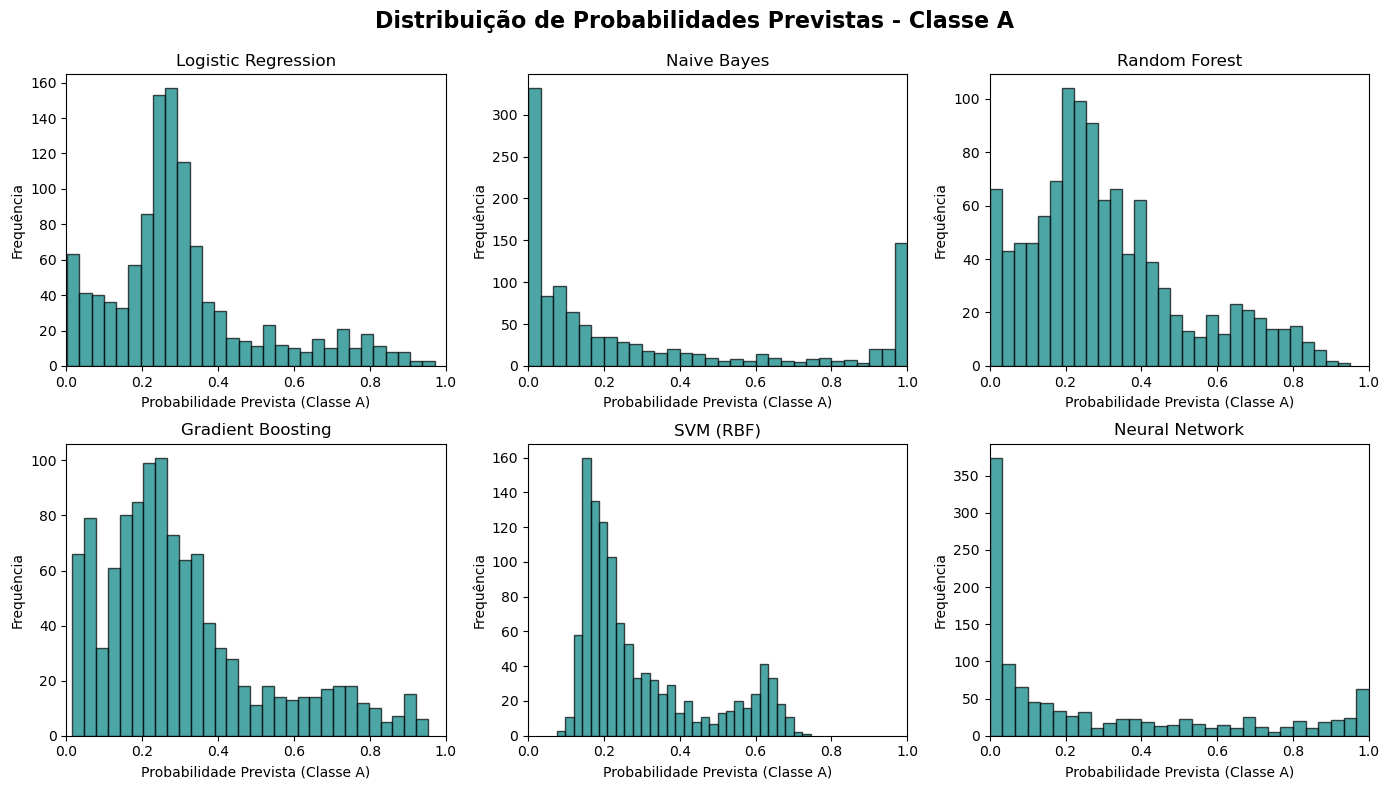

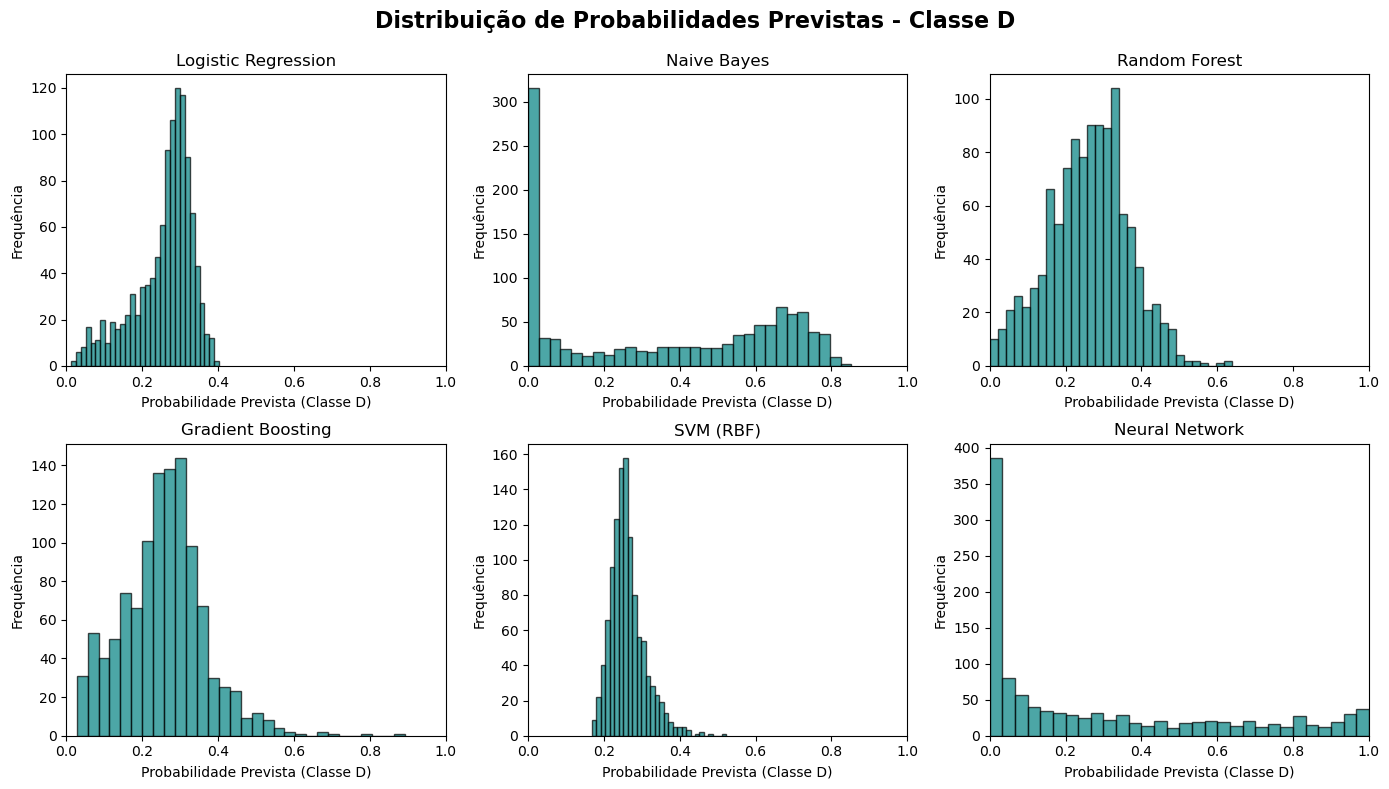

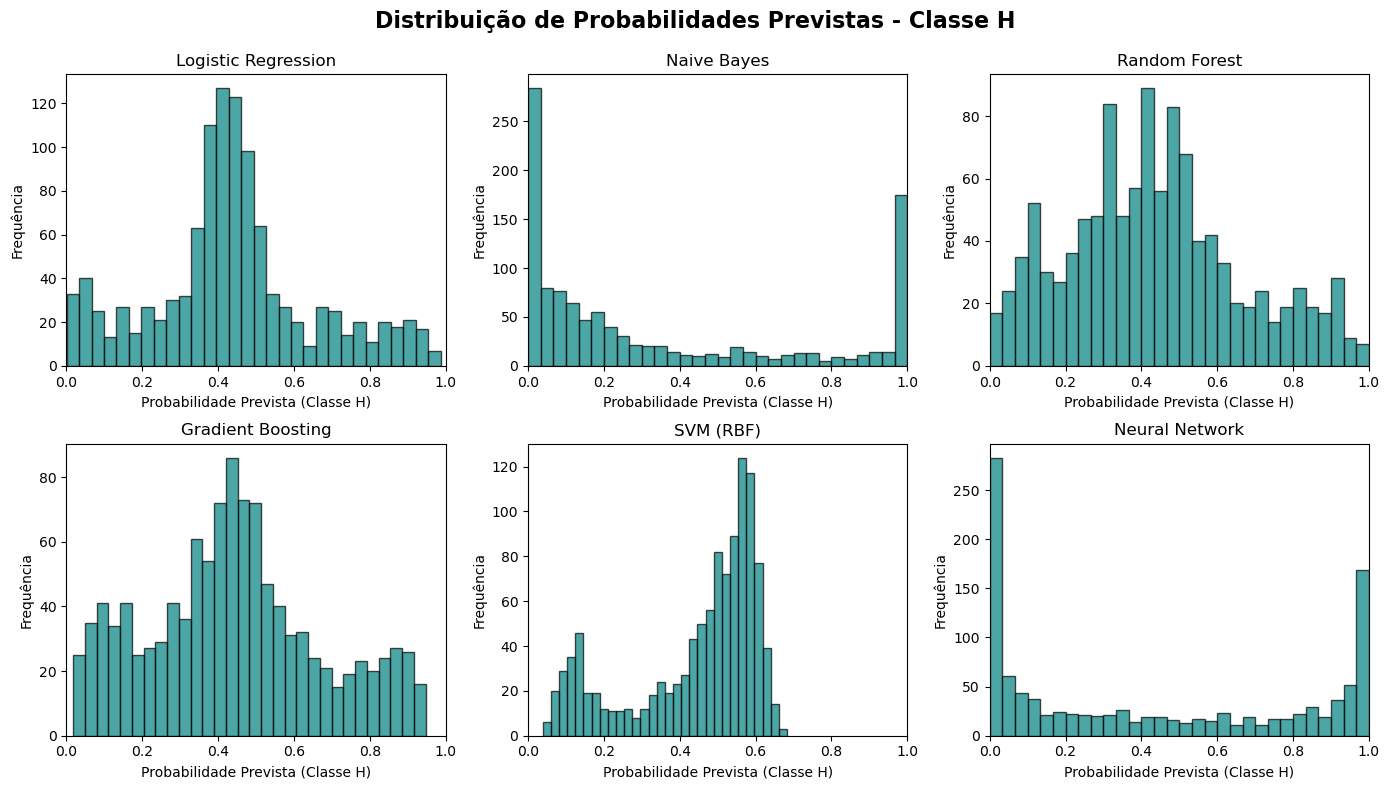

In [64]:
primeiro_modelo = list(classifiers.values())[0]
classes = primeiro_modelo.classes_

for class_idx, class_label in enumerate(classes):
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    fig.suptitle(f'Distribuição de Probabilidades Previstas - Classe {class_label}', fontsize=16, fontweight='bold')
    
    for idx, (name, clf) in enumerate(classifiers.items()):
        probs = clf.predict_proba(X_test_scaled)[:, class_idx]
        
        axes[idx].hist(probs, bins=30, edgecolor='black', alpha=0.7, color='teal')
        axes[idx].set_xlabel(f'Probabilidade Prevista (Classe {class_label})')
        axes[idx].set_ylabel('Frequência')
        axes[idx].set_title(f'{name}')

        axes[idx].set_xlim(0, 1)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90) 
    plt.show()

### 2. Conformal Prediction

Definimos prediction sets com garantia de cobertura (ex: 90%) utilizando o set de calibração.

In [65]:
def compute_coverage_clf(y_true, prediction_sets, classes):
    """
    Calcula a percentagem de vezes que a verdadeira classe está no conjunto previsto.
    y_true: array com os labels verdadeiros.
    prediction_sets: matriz booleana (n_amostras, n_classes) gerada pelo crepes.
    classes: array com as classes do modelo (ex: clf.classes_).
    """
    # Mapear as classes verdadeiras para os índices das colunas da matriz
    class_to_idx = {c: i for i, c in enumerate(classes)}
    y_true_idx = [class_to_idx[y] for y in y_true]
    
    # Verificar se a coluna correspondente à classe verdadeira é True
    is_covered = [prediction_sets[i, target_idx] for i, target_idx in enumerate(y_true_idx)]
    return np.mean(is_covered)

def compute_mean_set_size(prediction_sets):
    """
    Calcula o número médio de classes retornadas por amostra.
    """
    return np.mean(np.sum(prediction_sets, axis=1))



In [66]:
alpha = 0.1
results = []

print("="*60)
print(f"AVALIAÇÃO CONFORMAL PREDICTION (Confiança: {1-alpha:.0%})")
print("="*60)

for name, clf in classifiers.items():
    cp_clf = WrapClassifier(clf)
    
    cp_clf.calibrate(X_cal_scaled, y_cal)
    
    prediction_sets = cp_clf.predict_set(X_test_scaled, confidence=1-alpha)

    cov = compute_coverage_clf(y_test, prediction_sets, clf.classes_)
    size = compute_mean_set_size(prediction_sets)

    results.append({
        "Model": name,
        "Coverage": cov,
        "Target Coverage": 1 - alpha,
        "Mean Set Size": size
    })

df_cp_results = pd.DataFrame(results)

df_cp_results['Coverage'] = df_cp_results['Coverage'].apply(lambda x: f"{x:.2%}")
df_cp_results['Target Coverage'] = df_cp_results['Target Coverage'].apply(lambda x: f"{x:.0%}")
df_cp_results['Mean Set Size'] = df_cp_results['Mean Set Size'].apply(lambda x: f"{x:.3f}")

print(df_cp_results.to_string(index=False))

AVALIAÇÃO CONFORMAL PREDICTION (Confiança: 90%)
              Model Coverage Target Coverage Mean Set Size
Logistic Regression   89.35%             90%         2.212
        Naive Bayes   89.17%             90%         2.263
      Random Forest   89.44%             90%         2.324
  Gradient Boosting   88.81%             90%         2.242
          SVM (RBF)   89.44%             90%         2.376
     Neural Network   88.18%             90%         2.422


### 3. Calibração do Modelo

Análise de Reliability Diagram para a classe Vitória em Casa (H).

In [67]:
results_metrics = []

y_test_dummies = pd.get_dummies(y_test).values

for name, clf in classifiers.items():
    y_prob = clf.predict_proba(X_test_scaled)
    
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    
    brier = np.mean(np.sum((y_test_dummies - y_prob)**2, axis=1))

    logloss = log_loss(y_test, y_prob)
    
    results_metrics.append({
        "Classifier": name,
        "ROC AUC": auc,
        "Brier Score": brier,
        "Log Loss": logloss
    })


df_metrics = pd.DataFrame(results_metrics)

df_metrics = df_metrics.sort_values(by="ROC AUC", ascending=False).reset_index()
df_metrics.rename(columns={'index': 'Original Index'}, inplace=True)

df_metrics['ROC AUC'] = df_metrics['ROC AUC'].apply(lambda x: f"{x:.6f}")
df_metrics['Brier Score'] = df_metrics['Brier Score'].apply(lambda x: f"{x:.6f}")
df_metrics['Log Loss'] = df_metrics['Log Loss'].apply(lambda x: f"{x:.6f}")

print(df_metrics.to_string())

   Original Index           Classifier   ROC AUC Brier Score  Log Loss
0               0  Logistic Regression  0.686721    0.563169  0.954648
1               3    Gradient Boosting  0.678638    0.578513  0.976270
2               1          Naive Bayes  0.676227    0.747304  2.123157
3               2        Random Forest  0.671085    0.578744  0.981416
4               4            SVM (RBF)  0.638985    0.591185  0.994952
5               5       Neural Network  0.617905    0.827334  2.026583


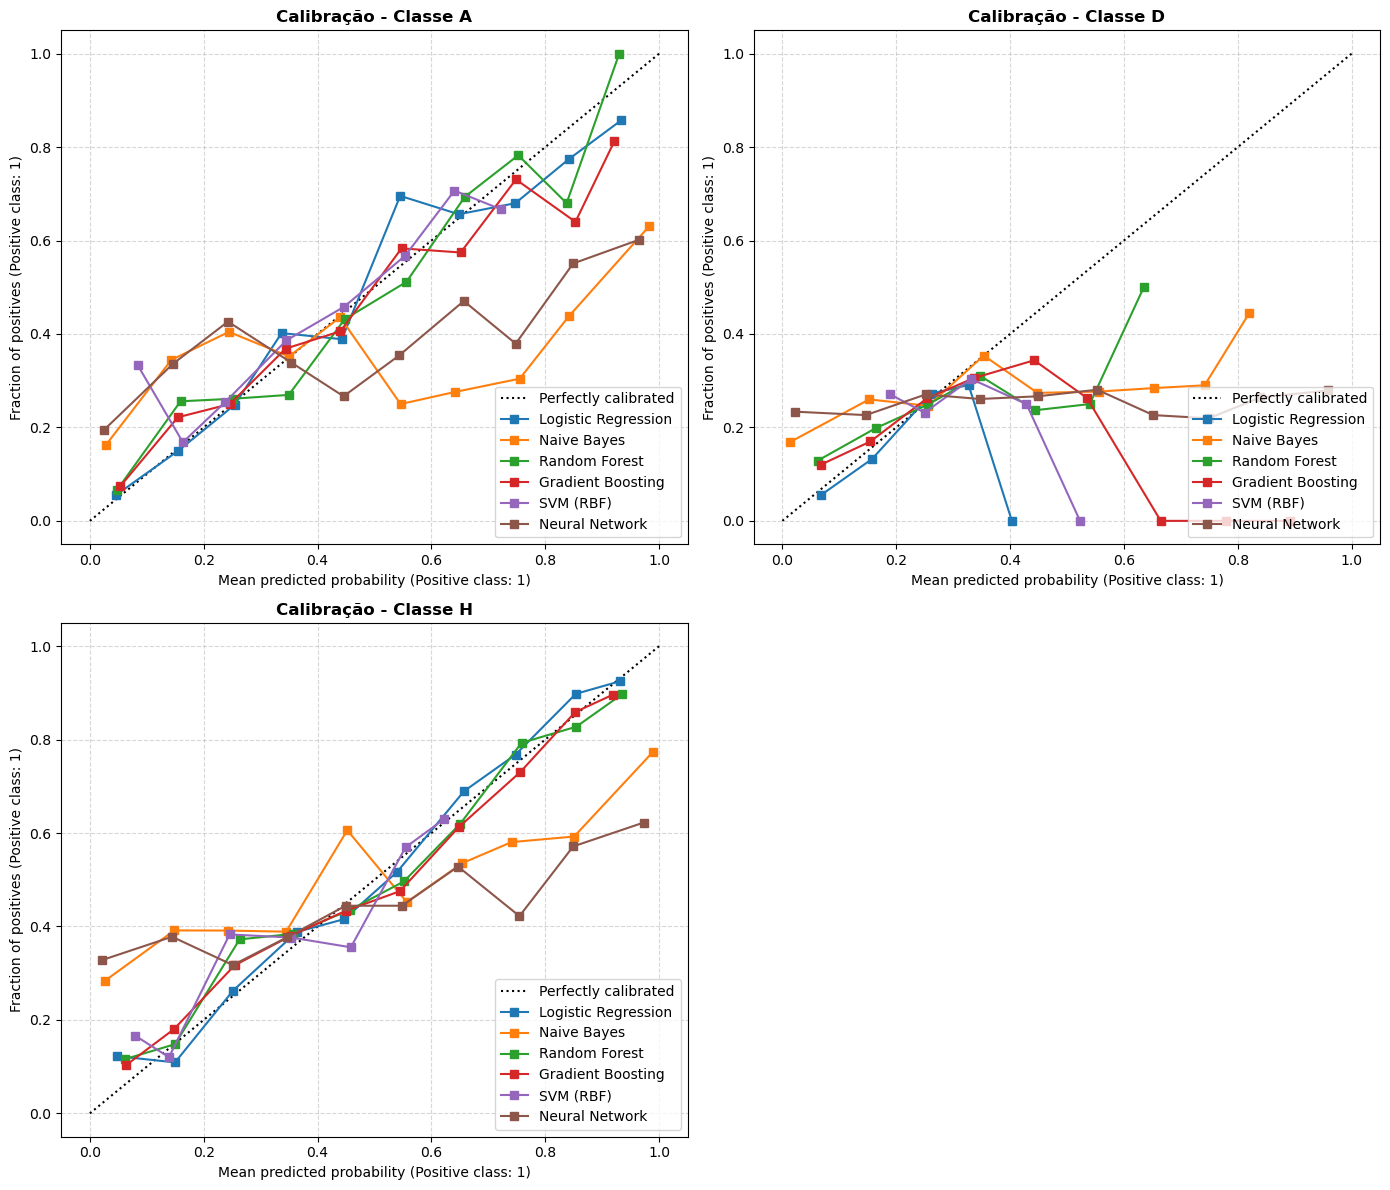

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import CalibrationDisplay

# 1. Obter as classes disponíveis a partir do primeiro classificador
primeiro_modelo = list(classifiers.values())[0]
classes = primeiro_modelo.classes_
n_classes = len(classes)

cols = 2
rows = (n_classes + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))

# Garantir que axes é uma lista flat (mesmo que haja apenas 1 linha)
if n_classes > 2:
    axes = axes.flatten()
elif n_classes == 2:
    axes = axes # Já é um array 1D
else:
    axes = [axes]

# 3. Iterar sobre cada classe
for idx, class_label in enumerate(classes):
    ax = axes[idx]
    
    # Binarizar o y_test para a classe atual
    y_test_binary = (y_test == class_label).astype(int)
    
    # Iterar sobre cada modelo e desenhar a curva na subplot atual
    for name, clf in classifiers.items():
        # Extrair as probabilidades da classe específica (idx)
        y_prob = clf.predict_proba(X_test_scaled)[:, idx]
        
        CalibrationDisplay.from_predictions(
            y_test_binary, 
            y_prob, 
            n_bins=10, 
            name=name, 
            ax=ax
        )
    
    # Formatar cada subplot
    ax.set_title(f'Calibração - Classe {class_label}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.5)

# 4. Remover subplots vazias (caso o número de classes seja ímpar)
for i in range(n_classes, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

A iniciar avaliação de calibração para todos os modelos...

 MODELO: LOGISTIC REGRESSION

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.5336         0.6867    0.9546              0.5632       0.0240
Calibração Sigmoid     0.5354         0.6784    0.9620              0.5669       0.0401
Calibração Isotonic    0.5264         0.6759    1.0210              0.5703       0.0280

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0134  0.0339  0.0314      0.1797  0.1848  0.2057
Calibração Sigmoid   0.0348  0.0185  0.0341      0.1794  0.1833  0.2042
Sem Calibração       0.0304  0.0212  0.0311      0.1798  

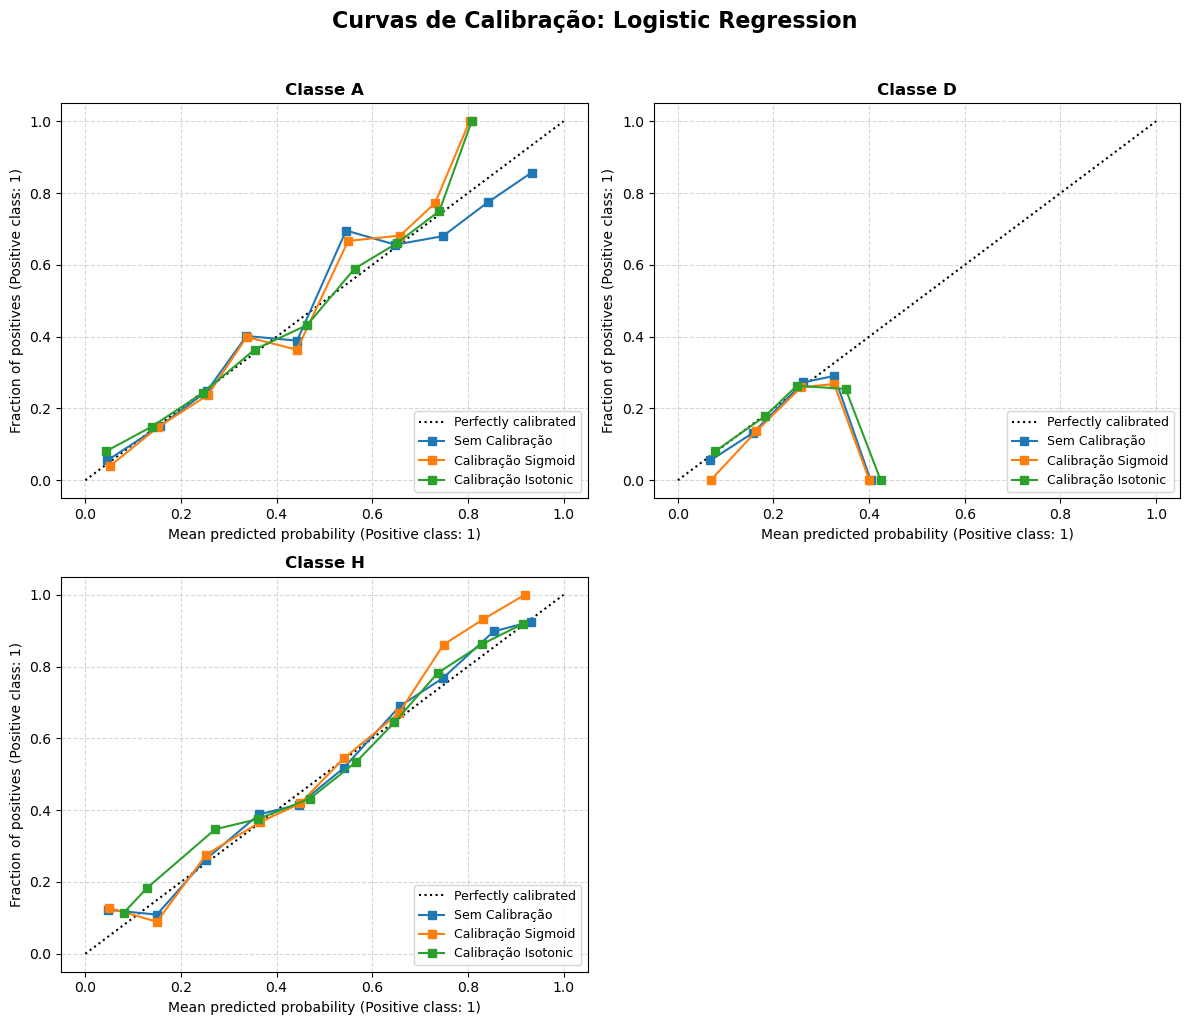

 MODELO: NAIVE BAYES

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.4655         0.6762    2.1232              0.7473       0.3082
Calibração Sigmoid     0.5004         0.6733    0.9916              0.5892       0.0440
Calibração Isotonic    0.5139         0.6699    0.9711              0.5769       0.0268

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0336  0.0241  0.0222      0.1860  0.1817  0.2091
Calibração Sigmoid   0.0415  0.0390  0.0396      0.1906  0.1848  0.2137
Sem Calibração       0.1899  0.2302  0.2135      0.2328  0.2548  0.2598
-----------------------------------------------------

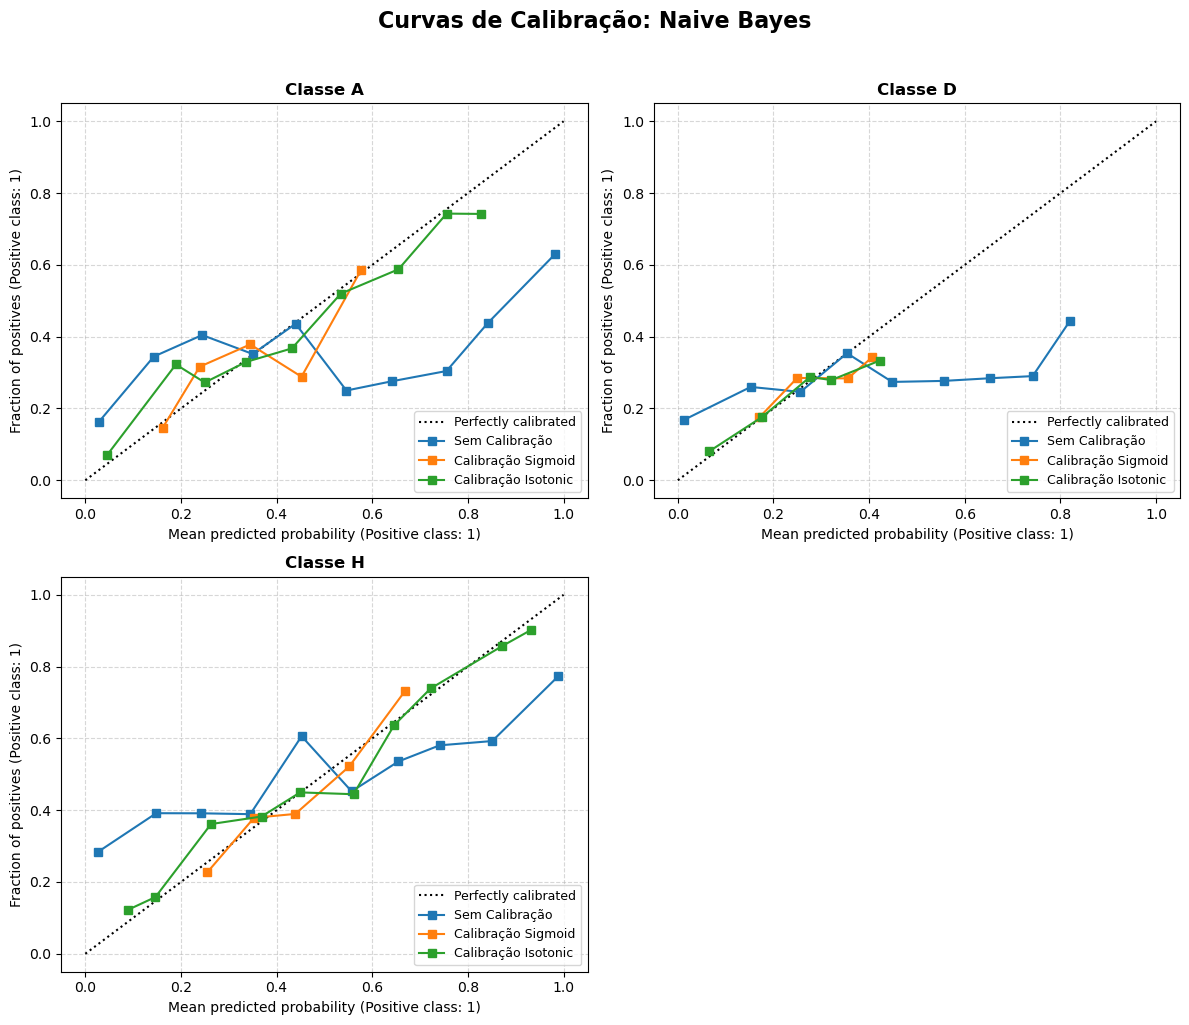

 MODELO: RANDOM FOREST

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.5192         0.6711    0.9814              0.5787       0.0444
Calibração Sigmoid     0.5273         0.6754    0.9717              0.5756       0.0460
Calibração Isotonic    0.5255         0.6724    1.0810              0.5723       0.0338

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0361  0.0266  0.0400      0.1819  0.1833  0.2071
Calibração Sigmoid   0.0373  0.0164  0.0592      0.1838  0.1828  0.2090
Sem Calibração       0.0457  0.0358  0.0465      0.1847  0.1859  0.2082
---------------------------------------------------

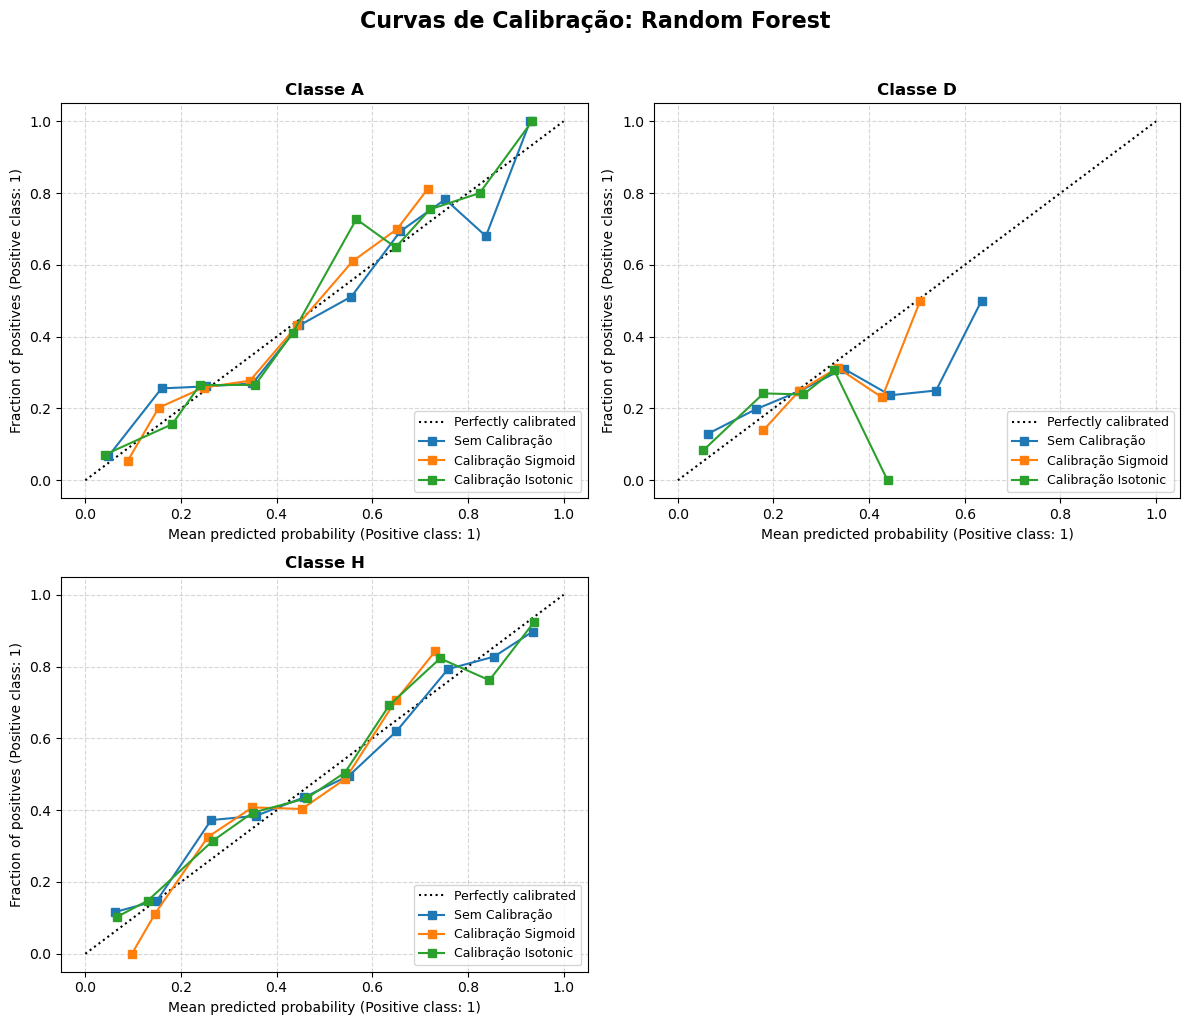

 MODELO: GRADIENT BOOSTING

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.5318         0.6786    0.9763              0.5785       0.0415
Calibração Sigmoid     0.5309         0.6783    0.9686              0.5744       0.0340
Calibração Isotonic    0.5300         0.6709    1.0373              0.5772       0.0251

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0274  0.0183  0.0422      0.1843  0.1843  0.2086
Calibração Sigmoid   0.0155  0.0208  0.0339      0.1837  0.1836  0.2071
Sem Calibração       0.0359  0.0326  0.0337      0.1861  0.1862  0.2062
-----------------------------------------------

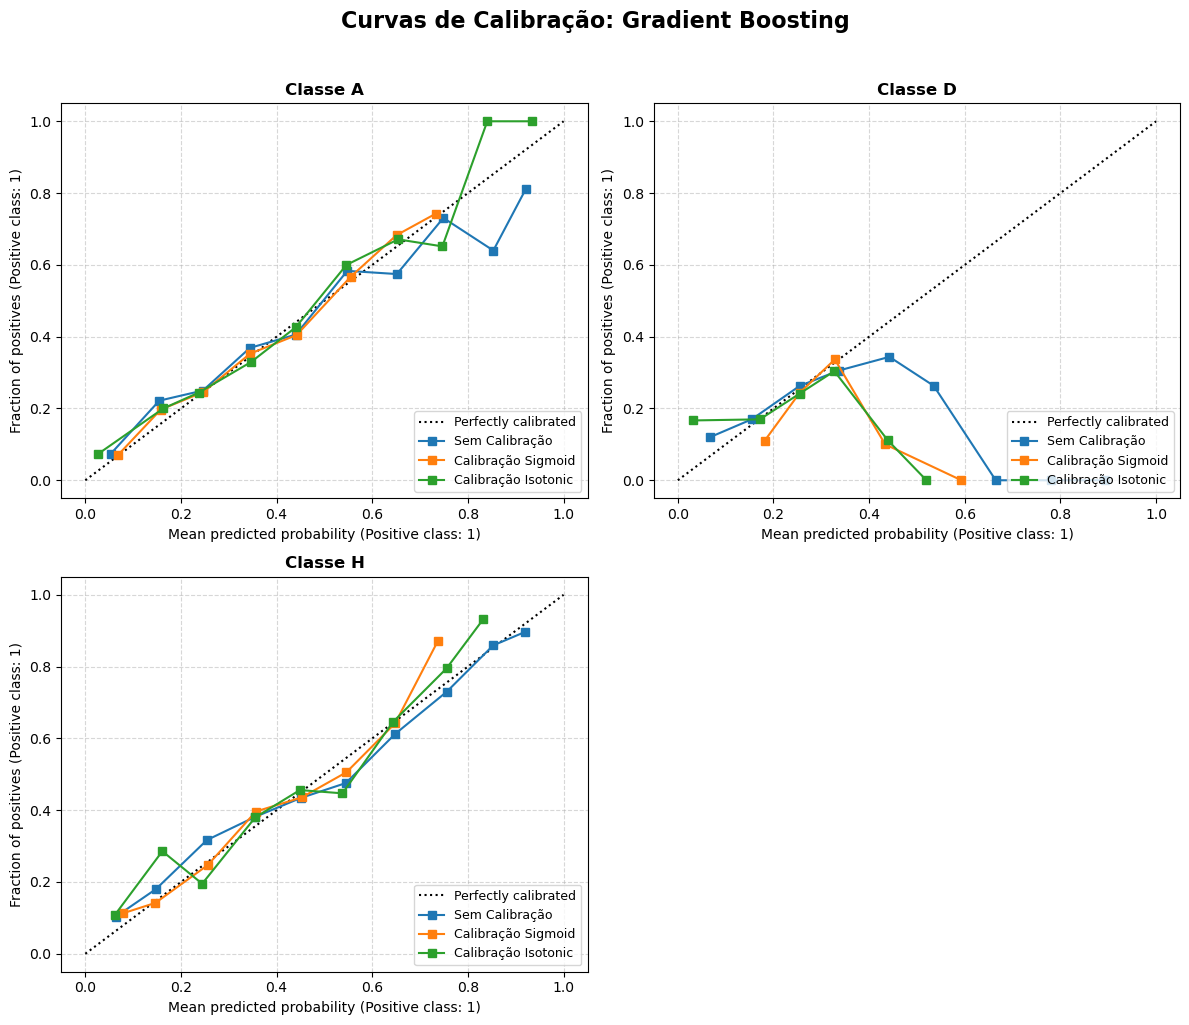

 MODELO: SVM (RBF)

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.5246         0.6390    0.9950              0.5912       0.0400
Calibração Sigmoid     0.5264         0.6481    1.0046              0.5988       0.0193
Calibração Isotonic    0.5363         0.6453    1.0535              0.5883       0.0241

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0400  0.0202  0.0370      0.1860  0.1862  0.2161
Calibração Sigmoid   0.0202  0.0119  0.0300      0.1888  0.1852  0.2248
Sem Calibração       0.0203  0.0254  0.0401      0.1851  0.1867  0.2194
-------------------------------------------------------

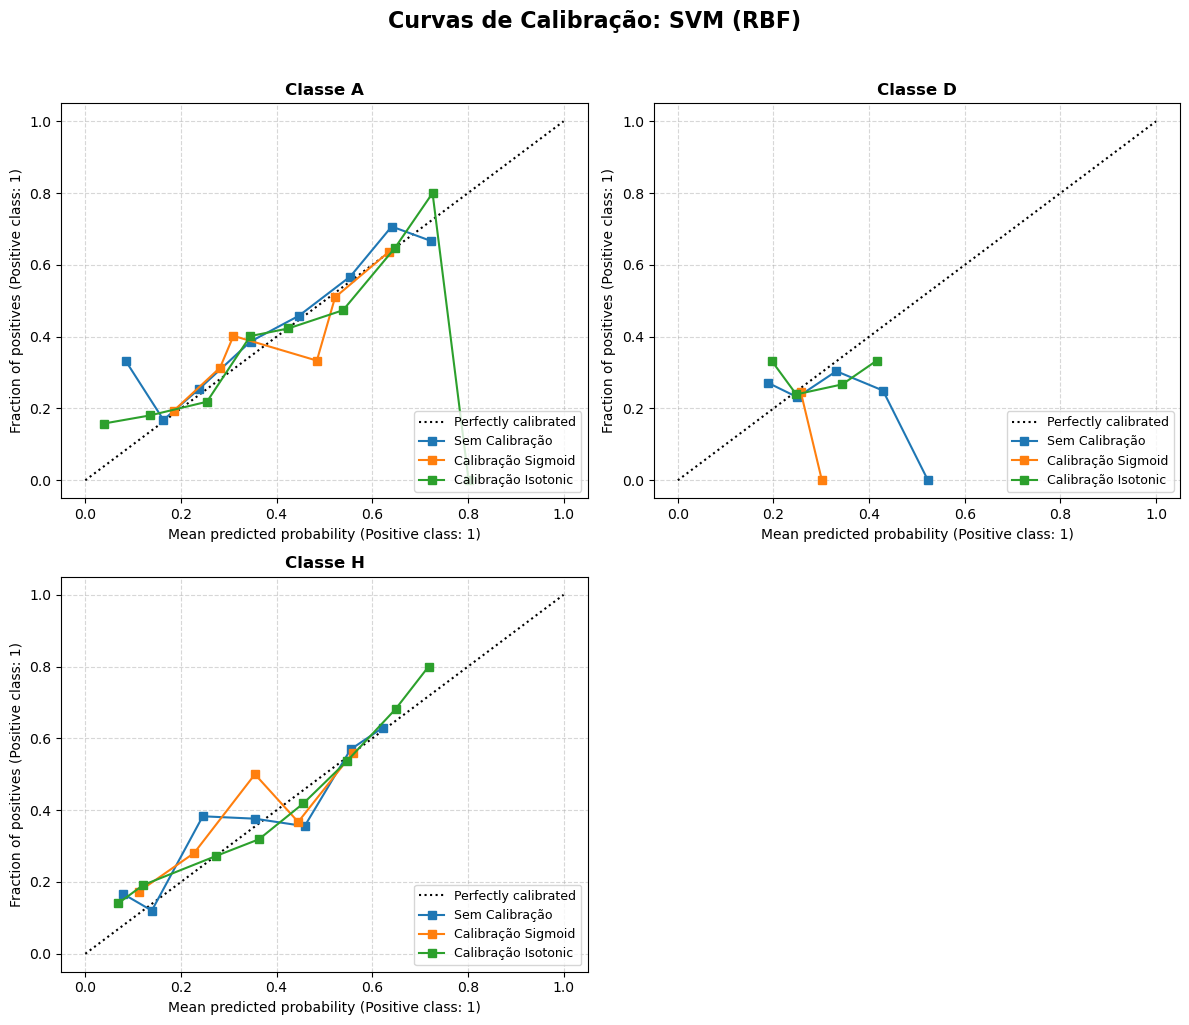

 MODELO: NEURAL NETWORK

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.4593         0.6179    2.0266              0.8273       0.3356
Calibração Sigmoid     0.5049         0.6243    1.0245              0.6138       0.0325
Calibração Isotonic    0.4987         0.6164    1.0231              0.6108       0.0213

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0239  0.0347  0.0369      0.1946  0.1894  0.2267
Calibração Sigmoid   0.0371  0.0162  0.0228      0.1984  0.1857  0.2297
Sem Calibração       0.1958  0.2536  0.2503      0.2396  0.2825  0.3052
--------------------------------------------------

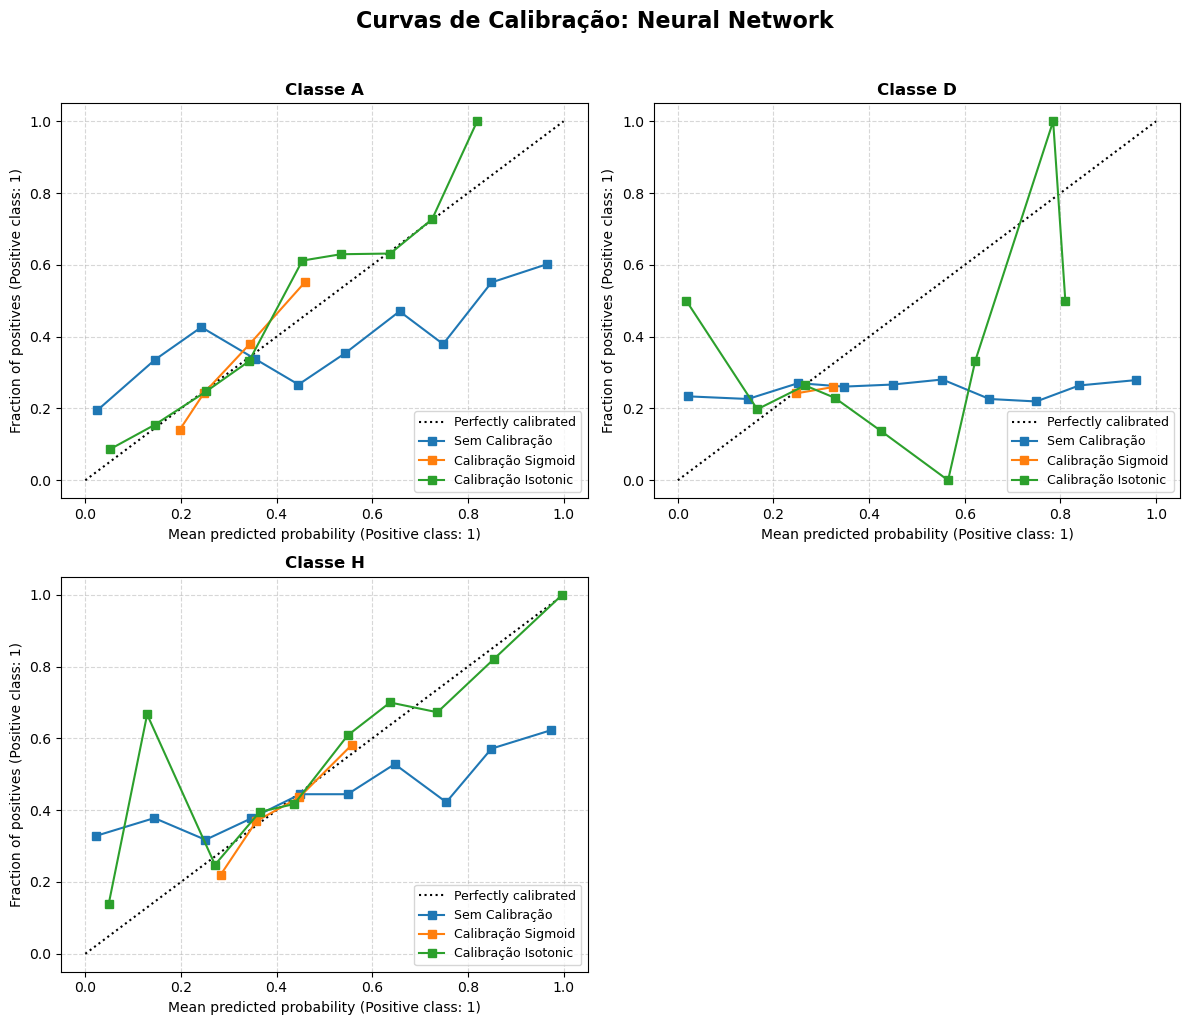


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 RANKING FINAL DE CALIBRAÇÃO (VENCEDOR NO TOPO)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
           Modelo Base  Melhor Configuração  Brier Score Global  Log Loss  ECE (Top-1)
0  Logistic Regression       Sem Calibração              0.5632    0.9546       0.0240
1        Random Forest  Calibração Isotonic              0.5723    1.0810       0.0338
2    Gradient Boosting   Calibração Sigmoid              0.5744    0.9686       0.0340
3          Naive Bayes  Calibração Isotonic              0.5769    0.9711       0.0268
4            SVM (RBF)  Calibração Isotonic              0.5883    1.0535       0.0241
5       Neural Network  Calibração Isotonic              0.6108    1.0231       0.0213

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 O MELHOR MODELO GERAL É: Logistic Regression
 USANDO A TÉCNICA:        Sem Calibração


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
from sklearn.frozen import FrozenEstimator

# 1. Funções ECE
def calculate_ece_multiclass(y_true, y_proba, classes, n_bins=10):
    """ECE Top-1 Global"""
    predictions = classes[np.argmax(y_proba, axis=1)]
    confidences = np.max(y_proba, axis=1)
    accuracies = (predictions == y_true).astype(int)
    
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            avg_confidence = confidences[in_bin].mean()
            avg_accuracy = accuracies[in_bin].mean()
            ece += prop_in_bin * np.abs(avg_accuracy - avg_confidence)
    return ece

def calculate_ece_binary(y_true_binary, y_prob_1d, n_bins=10):
    """ECE para uma única classe (One-vs-Rest)"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (y_prob_1d >= bin_boundaries[i]) & (y_prob_1d < bin_boundaries[i + 1])
        if i == n_bins - 1: # Incluir o 1.0 no último bin
            in_bin = (y_prob_1d >= bin_boundaries[i]) & (y_prob_1d <= bin_boundaries[i + 1])
            
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            avg_confidence = y_prob_1d[in_bin].mean()
            avg_accuracy = y_true_binary[in_bin].mean()
            ece += prop_in_bin * np.abs(avg_accuracy - avg_confidence)
    return ece

def analyze_multiclass_calibration(model_name, base_model, X_train, y_train, X_cal, y_cal, X_test, y_test, n_bins=10):
    global_results = []
    class_results = []
    probs_dict = {} 
    classes = np.unique(y_train)
    y_test_dummies = pd.get_dummies(y_test).values
    
    # ---------------------------------------------------------
    # Treino e Avaliação das 3 Configurações
    # ---------------------------------------------------------
    configs = [
        ('Sem Calibração', base_model),
        ('Calibração Sigmoid', CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='sigmoid')),
        ('Calibração Isotonic', CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='isotonic'))
    ]
    
    # Treinar modelo base primeiro
    base_model.fit(X_train_scaled, y_train)
    
    for config_name, model in configs:
        if config_name != 'Sem Calibração':
            model.fit(X_cal_scaled, y_cal) # Calibradores treinam em X_cal
            
        y_prob = model.predict_proba(X_test_scaled)
        y_pred = model.predict(X_test_scaled)
        probs_dict[config_name] = y_prob
        
        # Guardar Métricas Globais
        global_brier = np.mean(np.sum((y_test_dummies - y_prob)**2, axis=1))
        global_results.append({
            'Configuração': config_name,
            'Acurácia': accuracy_score(y_test, y_pred),
            'ROC-AUC (OVR)': roc_auc_score(y_test, y_prob, multi_class='ovr'),
            'Log Loss': log_loss(y_test, y_prob),
            'Brier Score Global': global_brier,
            'ECE (Top-1)': calculate_ece_multiclass(y_test, y_prob, classes, n_bins)
        })
        
        # Guardar Métricas Por Classe
        for idx, class_label in enumerate(classes):
            y_test_bin = (y_test == class_label).astype(int)
            y_prob_class = y_prob[:, idx]
            class_results.append({
                'Configuração': config_name,
                'Classe': class_label,
                'Brier Score': brier_score_loss(y_test_bin, y_prob_class),
                'ECE': calculate_ece_binary(y_test_bin, y_prob_class, n_bins)
            })

    # ---------------------------------------------------------
    # Apresentar Tabelas
    # ---------------------------------------------------------
    df_global = pd.DataFrame(global_results).set_index('Configuração')
    df_class = pd.DataFrame(class_results)
    
    print("\n[Métricas Globais]")
    print(df_global.round(4).to_string())
    
    print("\n[Métricas Detalhadas por Classe]")
    # Reorganizar tabela por classe para facilitar leitura (Pivot)
    df_class_pivot = df_class.pivot(index='Configuração', columns='Classe', values=['ECE', 'Brier Score'])
    print(df_class_pivot.round(4).to_string())
    print("-" * 80)
    
    # ---------------------------------------------------------
    # Plot Multiclasse
    # ---------------------------------------------------------
    n_classes = len(classes)
    cols = 2
    rows = (n_classes + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    if n_classes > 2: axes = axes.flatten()
    elif n_classes == 2: axes = axes
    else: axes = [axes]
        
    for idx, class_label in enumerate(classes):
        ax = axes[idx]
        y_test_binary = (y_test == class_label).astype(int)
        for config_name, y_prob_matrix in probs_dict.items():
            CalibrationDisplay.from_predictions(
                y_test_binary, y_prob_matrix[:, idx], n_bins=n_bins, name=config_name, ax=ax
            )
        ax.set_title(f'Classe {class_label}', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.5)

    for i in range(n_classes, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle(f'Curvas de Calibração: {model_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Retornar o melhor Brier Score e Log Loss deste modelo específico para o Ranking Final
    best_config_idx = df_global['Brier Score Global'].argmin()
    return {
        'Modelo Base': model_name,
        'Melhor Configuração': df_global.index[best_config_idx],
        'Brier Score Global': df_global['Brier Score Global'].iloc[best_config_idx],
        'Log Loss': df_global['Log Loss'].iloc[best_config_idx],
        'ECE (Top-1)': df_global['ECE (Top-1)'].iloc[best_config_idx]
    }

# ==============================================================================
# 3. CICLO PRINCIPAL: AVALIAR TUDO E ESCOLHER O VENCEDOR
# ==============================================================================
print("A iniciar avaliação de calibração para todos os modelos...\n")

leaderboard = []

for name, clf in classifiers.items():
    print("=" * 80)
    print(f" MODELO: {name.upper()}")
    print("=" * 80)
    
    best_of_model = analyze_multiclass_calibration(
        model_name=name,
        base_model=clf, 
        X_train=X_train_scaled, 
        y_train=y_train, 
        X_cal=X_cal_scaled, 
        y_cal=y_cal,
        X_test=X_test_scaled, 
        y_test=y_test
    )
    leaderboard.append(best_of_model)

# ==============================================================================
# 4. RANKING FINAL E SELEÇÃO DO MELHOR MODELO
# ==============================================================================
df_leaderboard = pd.DataFrame(leaderboard)
# Ordenar pelo Brier Score (o menor é o melhor)
df_leaderboard = df_leaderboard.sort_values(by=['Brier Score Global', 'Log Loss']).reset_index(drop=True)

print("\n" + "★" * 60)
print(" RANKING FINAL DE CALIBRAÇÃO (VENCEDOR NO TOPO)")
print("★" * 60)
print(df_leaderboard.round(4).to_string())

# Identificar o Vencedor Absoluto
vencedor_base = df_leaderboard.iloc[0]['Modelo Base']
vencedor_config = df_leaderboard.iloc[0]['Melhor Configuração']

print("\n" + "★" * 60)
print(f" O MELHOR MODELO GERAL É: {vencedor_base}")
print(f" USANDO A TÉCNICA:        {vencedor_config}")


A iniciar avaliação de calibração para todos os modelos...

 MODELO: LOGISTIC REGRESSION

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.5336         0.6867    0.9546              0.5632       0.0240
Calibração Sigmoid     0.5354         0.6784    0.9620              0.5669       0.0401
Calibração Isotonic    0.5264         0.6759    1.0210              0.5703       0.0280

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0134  0.0339  0.0314      0.1797  0.1848  0.2057
Calibração Sigmoid   0.0348  0.0185  0.0341      0.1794  0.1833  0.2042
Sem Calibração       0.0304  0.0212  0.0311      0.1798  

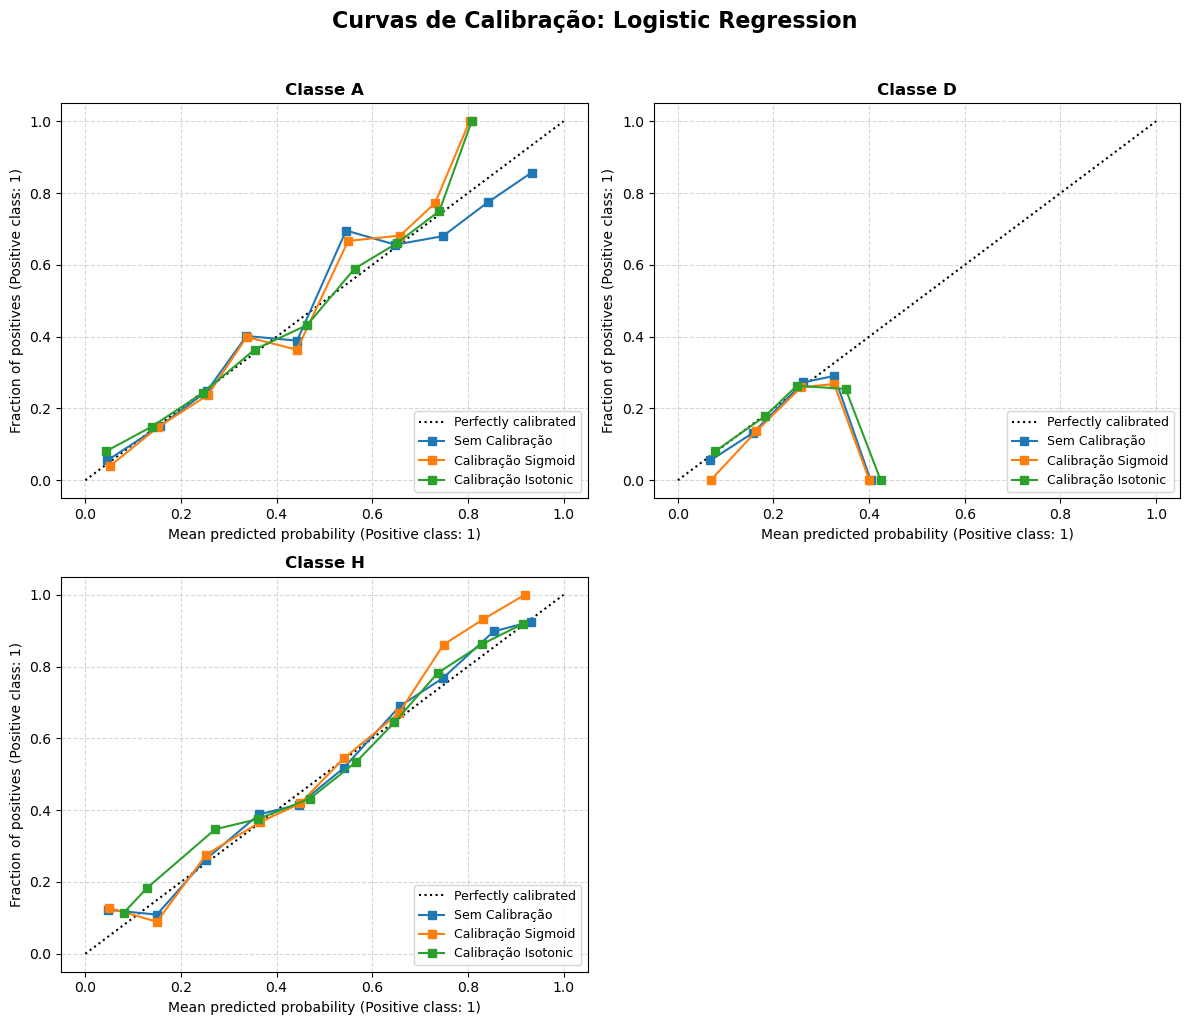

 MODELO: NAIVE BAYES

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.4655         0.6762    2.1232              0.7473       0.3082
Calibração Sigmoid     0.5004         0.6733    0.9916              0.5892       0.0440
Calibração Isotonic    0.5139         0.6699    0.9711              0.5769       0.0268

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0336  0.0241  0.0222      0.1860  0.1817  0.2091
Calibração Sigmoid   0.0415  0.0390  0.0396      0.1906  0.1848  0.2137
Sem Calibração       0.1899  0.2302  0.2135      0.2328  0.2548  0.2598
-----------------------------------------------------

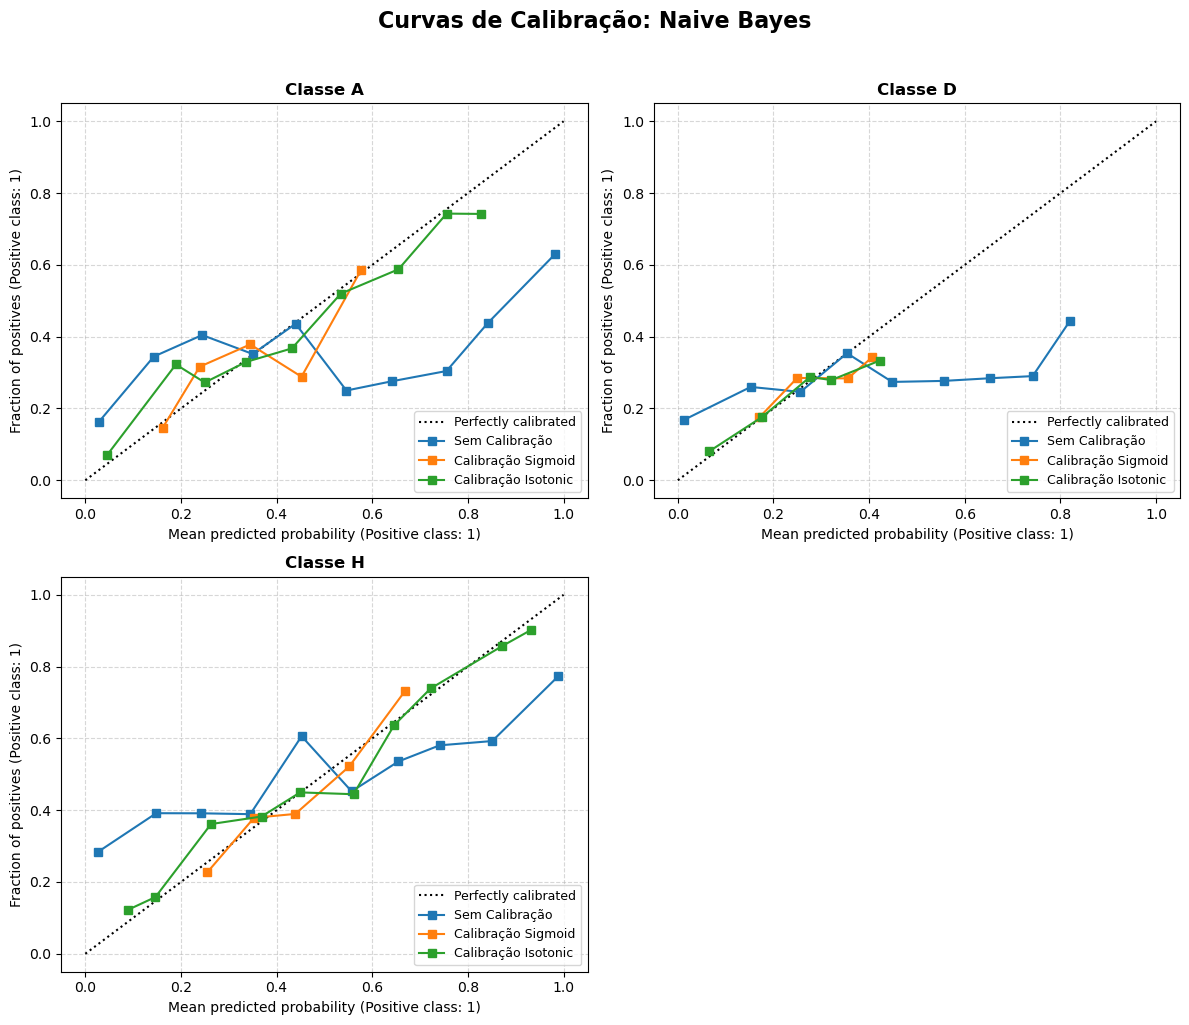

 MODELO: RANDOM FOREST

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.5192         0.6711    0.9814              0.5787       0.0444
Calibração Sigmoid     0.5273         0.6754    0.9717              0.5756       0.0460
Calibração Isotonic    0.5255         0.6724    1.0810              0.5723       0.0338

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0361  0.0266  0.0400      0.1819  0.1833  0.2071
Calibração Sigmoid   0.0373  0.0164  0.0592      0.1838  0.1828  0.2090
Sem Calibração       0.0457  0.0358  0.0465      0.1847  0.1859  0.2082
---------------------------------------------------

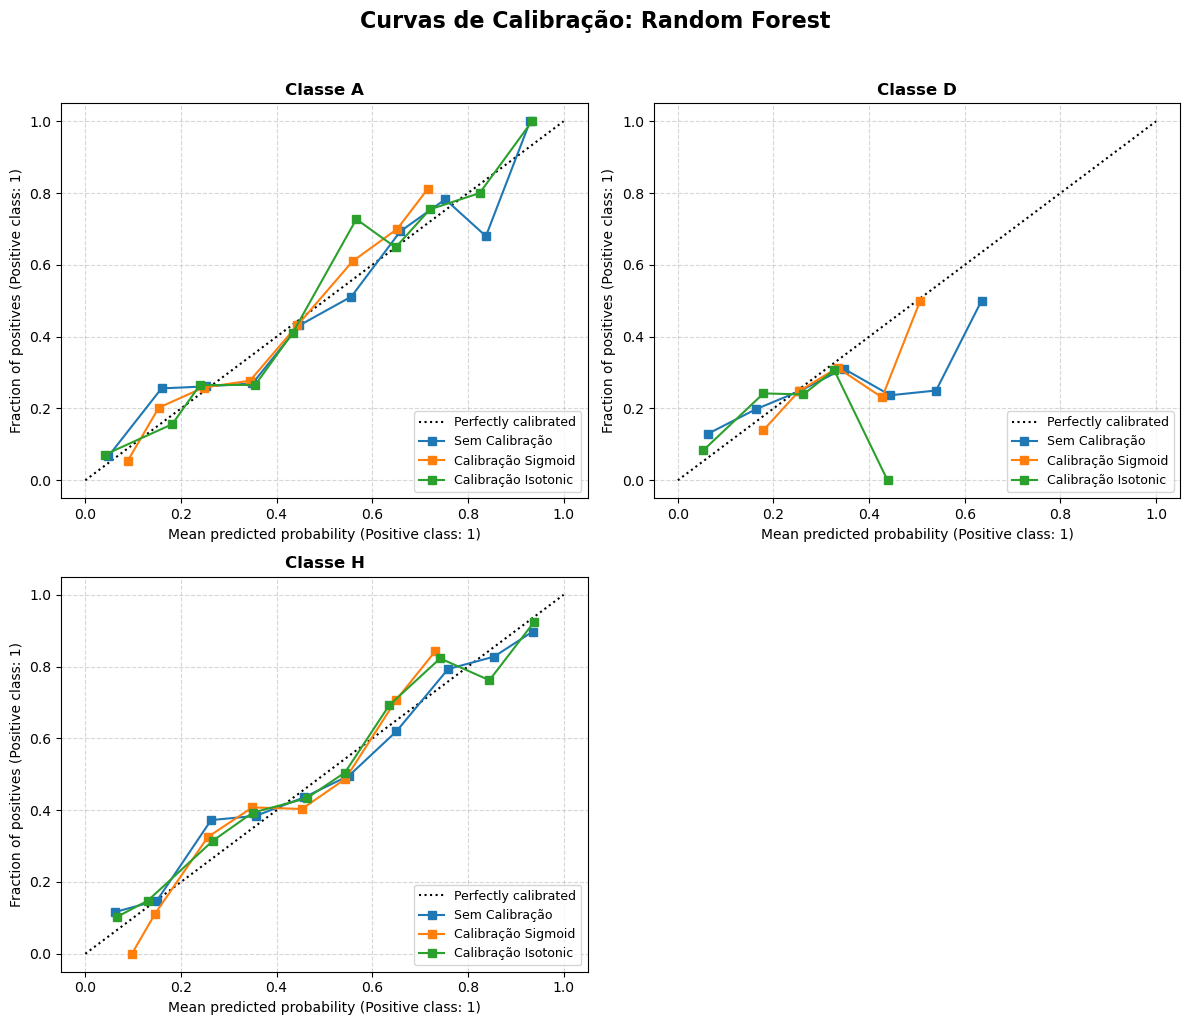

 MODELO: GRADIENT BOOSTING

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.5318         0.6786    0.9763              0.5785       0.0415
Calibração Sigmoid     0.5309         0.6783    0.9686              0.5744       0.0340
Calibração Isotonic    0.5300         0.6709    1.0373              0.5772       0.0251

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0274  0.0183  0.0422      0.1843  0.1843  0.2086
Calibração Sigmoid   0.0155  0.0208  0.0339      0.1837  0.1836  0.2071
Sem Calibração       0.0359  0.0326  0.0337      0.1861  0.1862  0.2062
-----------------------------------------------

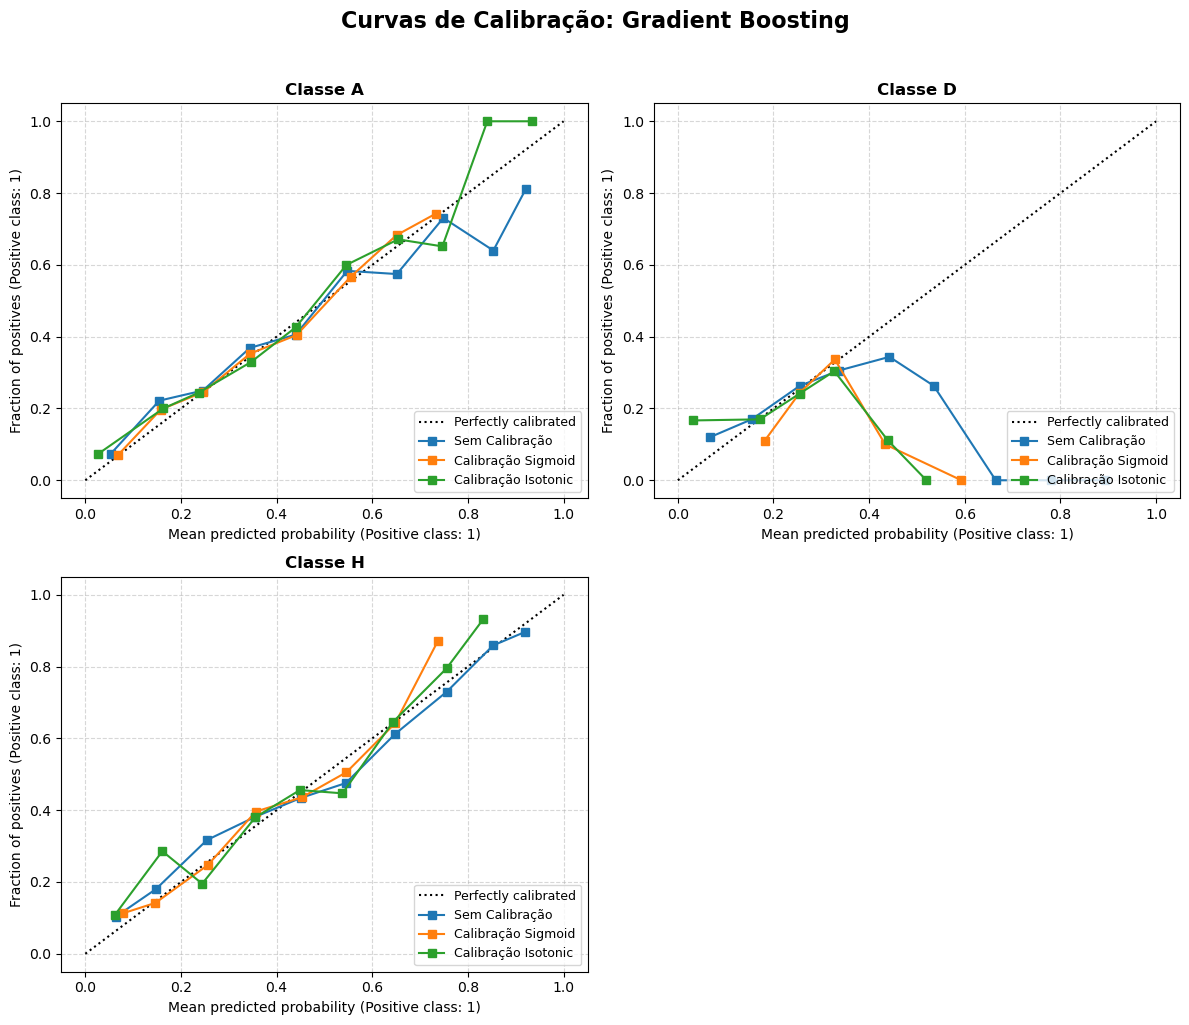

 MODELO: SVM (RBF)

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.5246         0.6390    0.9950              0.5912       0.0400
Calibração Sigmoid     0.5264         0.6481    1.0046              0.5988       0.0193
Calibração Isotonic    0.5363         0.6453    1.0535              0.5883       0.0241

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0400  0.0202  0.0370      0.1860  0.1862  0.2161
Calibração Sigmoid   0.0202  0.0119  0.0300      0.1888  0.1852  0.2248
Sem Calibração       0.0203  0.0254  0.0401      0.1851  0.1867  0.2194
-------------------------------------------------------

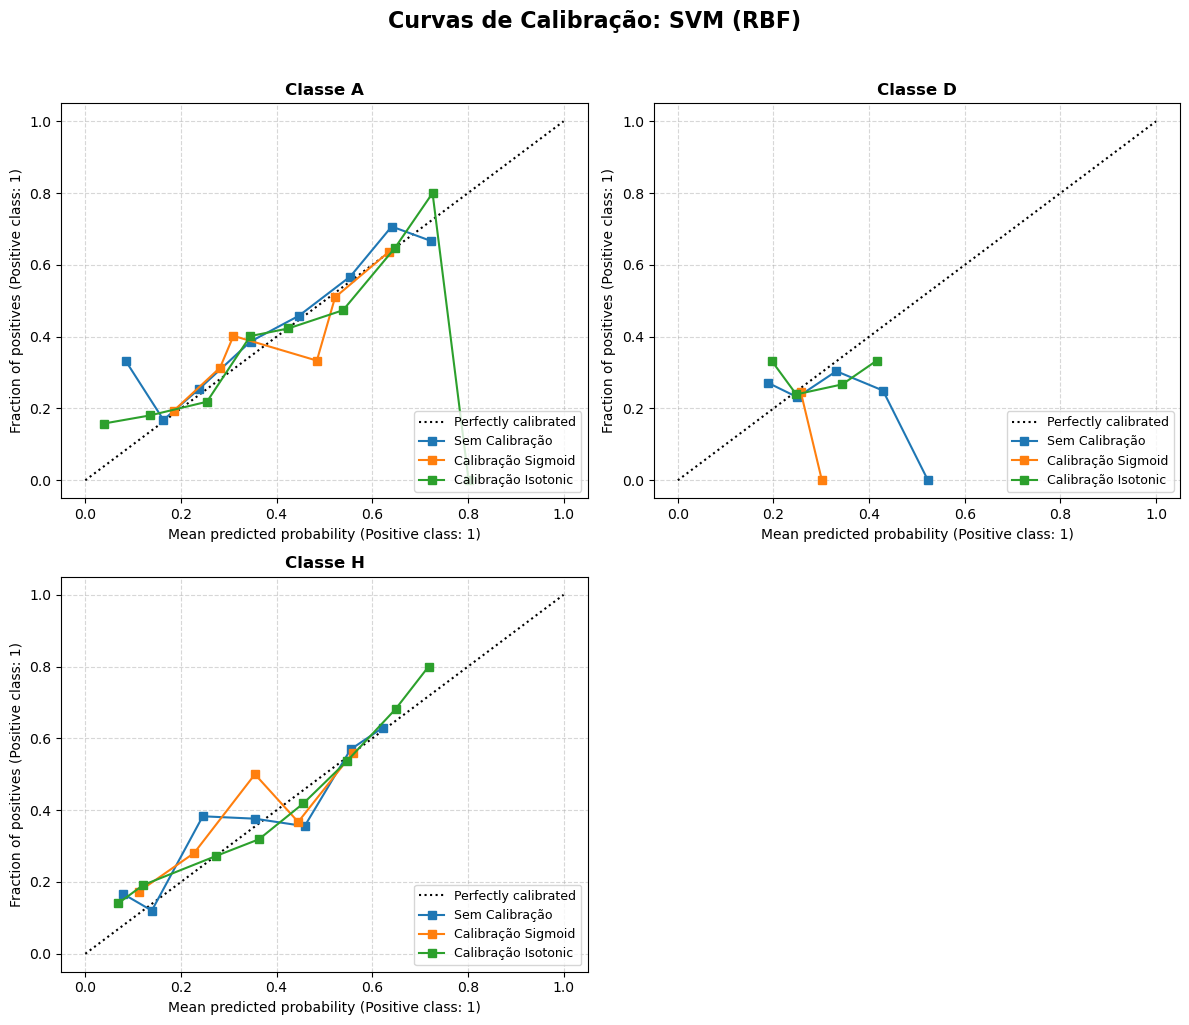

 MODELO: NEURAL NETWORK

[Métricas Globais]
                     Acurácia  ROC-AUC (OVR)  Log Loss  Brier Score Global  ECE (Top-1)
Configuração                                                                           
Sem Calibração         0.4593         0.6179    2.0266              0.8273       0.3356
Calibração Sigmoid     0.5049         0.6243    1.0245              0.6138       0.0325
Calibração Isotonic    0.4987         0.6164    1.0231              0.6108       0.0213

[Métricas Detalhadas por Classe]
                        ECE                 Brier Score                
Classe                    A       D       H           A       D       H
Configuração                                                           
Calibração Isotonic  0.0239  0.0347  0.0369      0.1946  0.1894  0.2267
Calibração Sigmoid   0.0371  0.0162  0.0228      0.1984  0.1857  0.2297
Sem Calibração       0.1958  0.2536  0.2503      0.2396  0.2825  0.3052
--------------------------------------------------

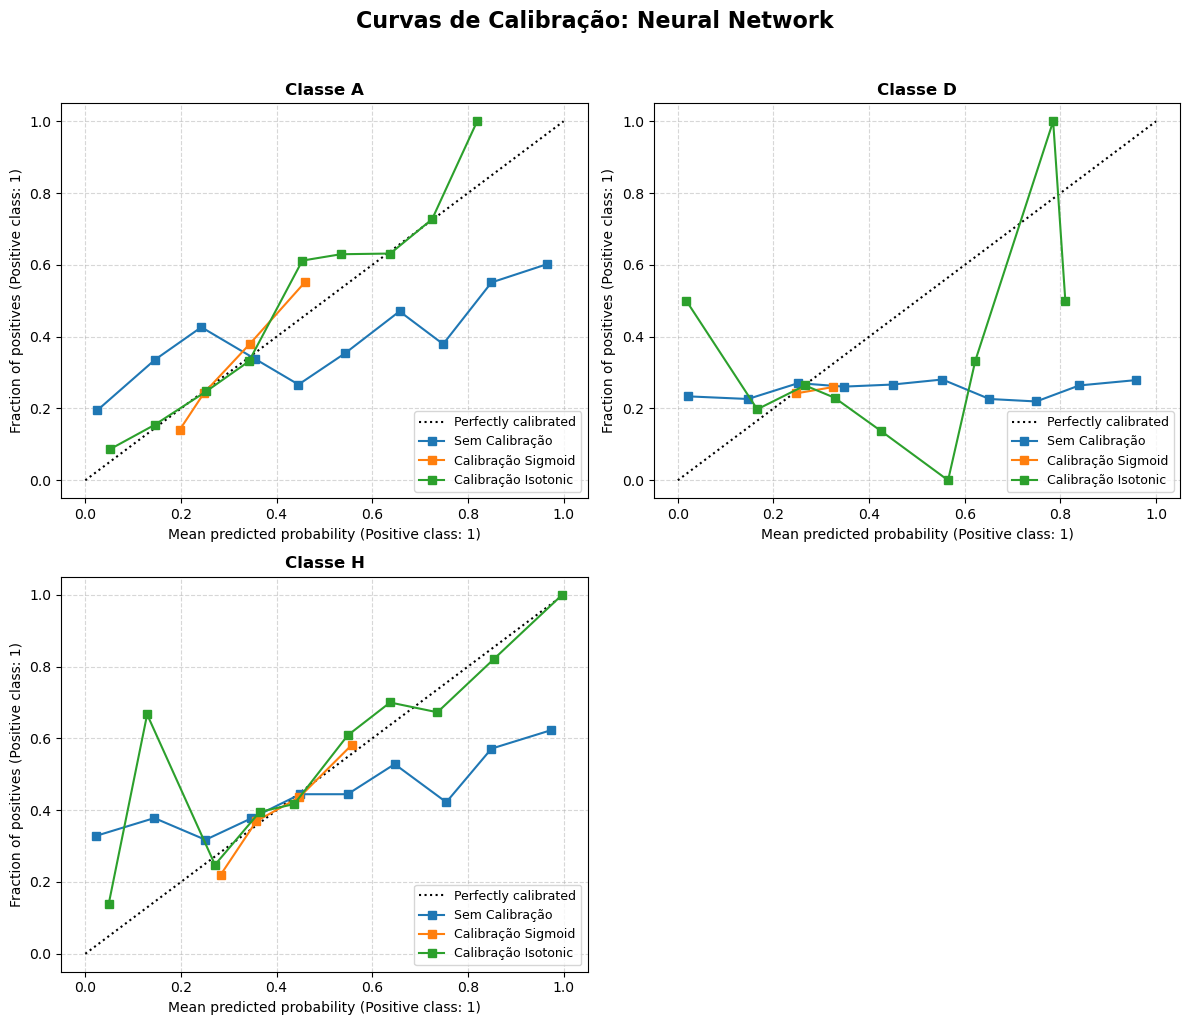


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 RANKING FINAL DE CALIBRAÇÃO (VENCEDOR NO TOPO)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
           Modelo Base  Melhor Configuração  Brier Score Global  Log Loss  ECE (Top-1)
0  Logistic Regression       Sem Calibração              0.5632    0.9546       0.0240
1        Random Forest  Calibração Isotonic              0.5723    1.0810       0.0338
2    Gradient Boosting   Calibração Sigmoid              0.5744    0.9686       0.0340
3          Naive Bayes  Calibração Isotonic              0.5769    0.9711       0.0268
4            SVM (RBF)  Calibração Isotonic              0.5883    1.0535       0.0241
5       Neural Network  Calibração Isotonic              0.6108    1.0231       0.0213

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 O MELHOR MODELO GERAL É: Logistic Regression
 USANDO A TÉCNICA:        Sem Calibração


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
from sklearn.frozen import FrozenEstimator

# 1. Funções ECE
def calculate_ece_multiclass(y_true, y_proba, classes, n_bins=10):
    """ECE Top-1 Global"""
    predictions = classes[np.argmax(y_proba, axis=1)]
    confidences = np.max(y_proba, axis=1)
    accuracies = (predictions == y_true).astype(int)
    
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            avg_confidence = confidences[in_bin].mean()
            avg_accuracy = accuracies[in_bin].mean()
            ece += prop_in_bin * np.abs(avg_accuracy - avg_confidence)
    return ece

def calculate_ece_binary(y_true_binary, y_prob_1d, n_bins=10):
    """ECE para uma única classe (One-vs-Rest)"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (y_prob_1d >= bin_boundaries[i]) & (y_prob_1d < bin_boundaries[i + 1])
        if i == n_bins - 1: # Incluir o 1.0 no último bin
            in_bin = (y_prob_1d >= bin_boundaries[i]) & (y_prob_1d <= bin_boundaries[i + 1])
            
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            avg_confidence = y_prob_1d[in_bin].mean()
            avg_accuracy = y_true_binary[in_bin].mean()
            ece += prop_in_bin * np.abs(avg_accuracy - avg_confidence)
    return ece

def analyze_multiclass_calibration(model_name, base_model, X_train, y_train, X_cal, y_cal, X_test, y_test, n_bins=10):
    global_results = []
    class_results = []
    probs_dict = {} 
    classes = np.unique(y_train)
    y_test_dummies = pd.get_dummies(y_test).values
    
    # ---------------------------------------------------------
    # Treino e Avaliação das 3 Configurações
    # ---------------------------------------------------------
    configs = [
        ('Sem Calibração', base_model),
        ('Calibração Sigmoid', CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='sigmoid')),
        ('Calibração Isotonic', CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='isotonic'))
    ]
    
    # Treinar modelo base primeiro
    base_model.fit(X_train_scaled, y_train)
    
    for config_name, model in configs:
        if config_name != 'Sem Calibração':
            model.fit(X_cal_scaled, y_cal) # Calibradores treinam em X_cal
            
        y_prob = model.predict_proba(X_test_scaled)
        y_pred = model.predict(X_test_scaled)
        probs_dict[config_name] = y_prob
        
        # Guardar Métricas Globais
        global_brier = np.mean(np.sum((y_test_dummies - y_prob)**2, axis=1))
        global_results.append({
            'Configuração': config_name,
            'Acurácia': accuracy_score(y_test, y_pred),
            'ROC-AUC (OVR)': roc_auc_score(y_test, y_prob, multi_class='ovr'),
            'Log Loss': log_loss(y_test, y_prob),
            'Brier Score Global': global_brier,
            'ECE (Top-1)': calculate_ece_multiclass(y_test, y_prob, classes, n_bins)
        })
        
        # Guardar Métricas Por Classe
        for idx, class_label in enumerate(classes):
            y_test_bin = (y_test == class_label).astype(int)
            y_prob_class = y_prob[:, idx]
            class_results.append({
                'Configuração': config_name,
                'Classe': class_label,
                'Brier Score': brier_score_loss(y_test_bin, y_prob_class),
                'ECE': calculate_ece_binary(y_test_bin, y_prob_class, n_bins)
            })

    # ---------------------------------------------------------
    # Apresentar Tabelas
    # ---------------------------------------------------------
    df_global = pd.DataFrame(global_results).set_index('Configuração')
    df_class = pd.DataFrame(class_results)
    
    print("\n[Métricas Globais]")
    print(df_global.round(4).to_string())
    
    print("\n[Métricas Detalhadas por Classe]")
    # Reorganizar tabela por classe para facilitar leitura (Pivot)
    df_class_pivot = df_class.pivot(index='Configuração', columns='Classe', values=['ECE', 'Brier Score'])
    print(df_class_pivot.round(4).to_string())
    print("-" * 80)
    
    # ---------------------------------------------------------
    # Plot Multiclasse
    # ---------------------------------------------------------
    n_classes = len(classes)
    cols = 2
    rows = (n_classes + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    if n_classes > 2: axes = axes.flatten()
    elif n_classes == 2: axes = axes
    else: axes = [axes]
        
    for idx, class_label in enumerate(classes):
        ax = axes[idx]
        y_test_binary = (y_test == class_label).astype(int)
        for config_name, y_prob_matrix in probs_dict.items():
            CalibrationDisplay.from_predictions(
                y_test_binary, y_prob_matrix[:, idx], n_bins=n_bins, name=config_name, ax=ax
            )
        ax.set_title(f'Classe {class_label}', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.5)

    for i in range(n_classes, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle(f'Curvas de Calibração: {model_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Retornar o melhor Brier Score e Log Loss deste modelo específico para o Ranking Final
    best_config_idx = df_global['Brier Score Global'].argmin()
    return {
        'Modelo Base': model_name,
        'Melhor Configuração': df_global.index[best_config_idx],
        'Brier Score Global': df_global['Brier Score Global'].iloc[best_config_idx],
        'Log Loss': df_global['Log Loss'].iloc[best_config_idx],
        'ECE (Top-1)': df_global['ECE (Top-1)'].iloc[best_config_idx]
    }

# ==============================================================================
# 3. CICLO PRINCIPAL: AVALIAR TUDO E ESCOLHER O VENCEDOR
# ==============================================================================
print("A iniciar avaliação de calibração para todos os modelos...\n")

leaderboard = []

for name, clf in classifiers.items():
    print("=" * 80)
    print(f" MODELO: {name.upper()}")
    print("=" * 80)
    
    best_of_model = analyze_multiclass_calibration(
        model_name=name,
        base_model=clf, 
        X_train=X_train_scaled, 
        y_train=y_train, 
        X_cal=X_cal_scaled, 
        y_cal=y_cal,
        X_test=X_test_scaled, 
        y_test=y_test
    )
    leaderboard.append(best_of_model)

# ==============================================================================
# 4. RANKING FINAL E SELEÇÃO DO MELHOR MODELO
# ==============================================================================
df_leaderboard = pd.DataFrame(leaderboard)
# Ordenar pelo Brier Score (o menor é o melhor)
df_leaderboard = df_leaderboard.sort_values(by=['Brier Score Global', 'Log Loss']).reset_index(drop=True)

print("\n" + "★" * 60)
print(" RANKING FINAL DE CALIBRAÇÃO (VENCEDOR NO TOPO)")
print("★" * 60)
print(df_leaderboard.round(4).to_string())

# Identificar o Vencedor Absoluto
vencedor_base = df_leaderboard.iloc[0]['Modelo Base']
vencedor_config = df_leaderboard.iloc[0]['Melhor Configuração']

print("\n" + "★" * 60)
print(f" O MELHOR MODELO GERAL É: {vencedor_base}")
print(f" USANDO A TÉCNICA:        {vencedor_config}")


### 4. Otimização de Hiperparâmetros (Bayesian Optimization)

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from sklearn.linear_model import LogisticRegression

search_spaces_logreg = {
    'C': Real(1e-4, 1e+2, prior='log-uniform'), 
    'l1_ratio': Real(0.0, 1.0) 
}

modelo_base_lr = LogisticRegression(
    penalty='elasticnet', 
    solver='saga', 
    max_iter=2000, 
    random_state=42
)

# 3. Executar a Otimização Bayesiana
bayes_search_lr = BayesSearchCV(
    estimator=modelo_base_lr,
    search_spaces=search_spaces_logreg,
    n_iter=30,              
    cv=5,                   
    scoring='neg_log_loss',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 3. Executar a Otimização Bayesiana
print("A procurar os melhores parâmetros para a Regressão Logística (Multiclasse)...")
bayes_search_lr.fit(X_train_scaled, y_train)

print("\n" + "★"*50)
print(f"Melhores parâmetros encontrados: {bayes_search_lr.best_params_}")
print(f"Melhor CV Score (Log Loss): {-bayes_search_lr.best_score_:.4f}")
print("★"*50 + "\n")

# 4. Extrair o modelo campeão
best_logreg = bayes_search_lr.best_estimator_

# 5. Avaliação Completa
print("=" * 80)
print(" AVALIAÇÃO DE CALIBRAÇÃO DO MODELO OTIMIZADO (BAYES OPT)")
print("=" * 80)

analyze_multiclass_calibration(
    model_name="Logistic Regression (Optimized)",
    base_model=best_logreg, 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_cal=X_cal_scaled, 
    y_cal=y_cal,
    X_test=X_test_scaled, 
    y_test=y_test
)

A procurar os melhores parâmetros para a Regressão Logística (Multiclasse)...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

# Parte 3: Teoria de Utilidade e Tomada de Decisão

### 1. Utilidade: Modelo vs Odds

Identificação de discrepâncias significativas entre o modelo e as odds de mercado.

In [ ]:
import pandas as pd
import numpy as np

def avaliar_utilidade_modelo(modelo, X_test_scaled, df_test_original):
    """
    Avalia a utilidade do modelo de Regressão Logística comparando com as odds.
    
    Parâmetros:
    modelo: O objeto 'best_logreg' treinado.
    X_test_scaled: Matriz de features do teste padronizada.
    df_test_original: O DataFrame original contendo as colunas 'h_odds', 'd_odds', 'a_odds' e 'result'.
    """
    
    # 1. Obter probabilidades previstas pelo modelo (Ordem: A, D, H)
    probs = modelo.predict_proba(X_test_scaled)
    
    # 2. Criar DataFrame de trabalho com as Odds e o Resultado Real
    # Usamos o índice de df_test_original para garantir que os dados batem
    util_df = df_test_original[['h_odds', 'd_odds', 'a_odds', 'result']].copy()
    
    util_df['prob_A'] = probs[:, 0]
    util_df['prob_D'] = probs[:, 1]
    util_df['prob_H'] = probs[:, 2]
    
    # 3. Calcular Valor Esperado (EV)
    util_df['ev_H'] = (util_df['prob_H'] * util_df['h_odds']) - 1
    util_df['ev_D'] = (util_df['prob_D'] * util_df['d_odds']) - 1
    util_df['ev_A'] = (util_df['prob_A'] * util_df['a_odds']) - 1
    
    # 4. Identificar a melhor aposta segundo o Princípio da Máxima Utilidade Esperada
    util_df['max_ev'] = util_df[['ev_H', 'ev_D', 'ev_A']].max(axis=1)
    util_df['sugestao'] = util_df[['ev_H', 'ev_D', 'ev_A']].idxmax(axis=1).str.replace('ev_', '')
    
    # 5. Filtrar Value Bets (Onde o modelo discorda significativamente das odds: EV > 0)
    value_bets = util_df[util_df['max_ev'] > 0].copy()
    
    # Calcular lucro real das sugestões (Se acertou, ganha (odds-1), se errou, perde 1)
    def calcular_lucro(row):
        if row['sugestao'] == row['result']:
            col_odd = row['sugestao'].lower() + '_odds'
            return row[col_odd] - 1
        return -1
    
    value_bets['lucro_real'] = value_bets.apply(calcular_lucro, axis=1)
    
    # 6. Preparar resultados para o print
    resultados = {
        "total_testados": len(util_df),
        "qtd_value_bets": len(value_bets),
        "ev_teorico_medio": value_bets['max_ev'].mean() if not value_bets.empty else 0,
        "lucro_total_acumulado": value_bets['lucro_real'].sum() if not value_bets.empty else 0,
        "detalhes": value_bets[['sugestao', 'result', 'max_ev', 'lucro_real']]
    }
    
    return resultados

res_util = avaliar_utilidade_modelo(best_logreg, X_test_scaled, df.loc[y_test.index])

print(f"Jogos no Teste: {res_util['total_testados']}")
print(f"Value Bets encontradas: {res_util['qtd_value_bets']}")
print(f"Lucro Real Acumulado: {res_util['lucro_total_acumulado']:.2f} unidades")
print("\nTop 5 Apostas com maior discordância (EV):")
print(res_util['detalhes'].sort_values(by='max_ev', ascending=False).head())

Jogos no Teste: 1117
Value Bets encontradas: 577
Lucro Real Acumulado: -62.55 unidades

Top 5 Apostas com maior discordância (EV):
     sugestao result    max_ev  lucro_real
5182        D      H  0.294721       -1.00
4486        D      A  0.234019       -1.00
5286        H      D  0.226682       -1.00
4059        D      D  0.186793        3.50
3468        H      H  0.171403        1.37


In [ ]:
def analyze_multiclass_calibration(model_name, base_model, X_train, y_train, X_cal, y_cal, X_test, y_test, n_bins=10):
    global_results = []
    class_results = []
    probs_dict = {} 
    classes = np.unique(y_train)
    y_test_dummies = pd.get_dummies(y_test).values
    
    # ---------------------------------------------------------
    # Treino e Avaliação das 3 Configurações
    # ---------------------------------------------------------
    configs = [
        ('Sem Calibração', base_model),
        ('Calibração Sigmoid', CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='sigmoid')),
        ('Calibração Isotonic', CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='isotonic'))
    ]
    
    # Treinar modelo base primeiro
    base_model.fit(X_train_scaled, y_train)
    
    for config_name, model in configs:
        if config_name != 'Sem Calibração':
            model.fit(X_cal_scaled, y_cal) # Calibradores treinam em X_cal
            
        y_prob = model.predict_proba(X_test_scaled)
        y_pred = model.predict(X_test_scaled)
        probs_dict[config_name] = y_prob
        
        # Guardar Métricas Globais
        global_brier = np.mean(np.sum((y_test_dummies - y_prob)**2, axis=1))
        global_results.append({
            'Configuração': config_name,
            'Acurácia': accuracy_score(y_test, y_pred),
            'ROC-AUC (OVR)': roc_auc_score(y_test, y_prob, multi_class='ovr'),
            'Log Loss': log_loss(y_test, y_prob),
            'Brier Score Global': global_brier,
            'ECE (Top-1)': calculate_ece_multiclass(y_test, y_prob, classes, n_bins)
        })
        
        # Guardar Métricas Por Classe
        for idx, class_label in enumerate(classes):
            y_test_bin = (y_test == class_label).astype(int)
            y_prob_class = y_prob[:, idx]
            class_results.append({
                'Configuração': config_name,
                'Classe': class_label,
                'Brier Score': brier_score_loss(y_test_bin, y_prob_class),
                'ECE': calculate_ece_binary(y_test_bin, y_prob_class, n_bins)
            })

    # ---------------------------------------------------------
    # Apresentar Tabelas
    # ---------------------------------------------------------
    df_global = pd.DataFrame(global_results).set_index('Configuração')
    df_class = pd.DataFrame(class_results)
    
    print("\n[Métricas Globais]")
    print(df_global.round(4).to_string())
    
    print("\n[Métricas Detalhadas por Classe]")
    # Reorganizar tabela por classe para facilitar leitura (Pivot)
    df_class_pivot = df_class.pivot(index='Configuração', columns='Classe', values=['ECE', 'Brier Score'])
    print(df_class_pivot.round(4).to_string())
    print("-" * 80)
    
    # ---------------------------------------------------------
    # Plot Multiclasse
    # ---------------------------------------------------------
    n_classes = len(classes)
    cols = 2
    rows = (n_classes + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    if n_classes > 2: axes = axes.flatten()
    elif n_classes == 2: axes = axes
    else: axes = [axes]
        
    for idx, class_label in enumerate(classes):
        ax = axes[idx]
        y_test_binary = (y_test == class_label).astype(int)
        for config_name, y_prob_matrix in probs_dict.items():
            CalibrationDisplay.from_predictions(
                y_test_binary, y_prob_matrix[:, idx], n_bins=n_bins, name=config_name, ax=ax
            )
        ax.set_title(f'Classe {class_label}', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.5)

    for i in range(n_classes, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle(f'Curvas de Calibração: {model_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Retornar o melhor Brier Score e Log Loss deste modelo específico para o Ranking Final
    best_config_idx = df_global['Brier Score Global'].argmin()
    return {
        'Modelo Base': model_name,
        'Melhor Configuração': df_global.index[best_config_idx],
        'Brier Score Global': df_global['Brier Score Global'].iloc[best_config_idx],
        'Log Loss': df_global['Log Loss'].iloc[best_config_idx],
        'ECE (Top-1)': df_global['ECE (Top-1)'].iloc[best_config_idx]
    }




=== Comparação de Calibração e Utilidade: Regressão Logística ===
                     Log Loss  Brier Score     ECE  Acurácia  Qtd Value Bets  Lucro Total (un)  ROI (%)
Configuração                                                                                           
Sem Calibração         0.9511       0.5617  0.0267    0.5407             577            -62.55 -10.8406
Calibração Sigmoid     0.9606       0.5670  0.0475    0.5407             636           -124.85 -19.6305
Calibração Isotonic    1.1398       0.5696  0.0300    0.5461             842           -127.77 -15.1746


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


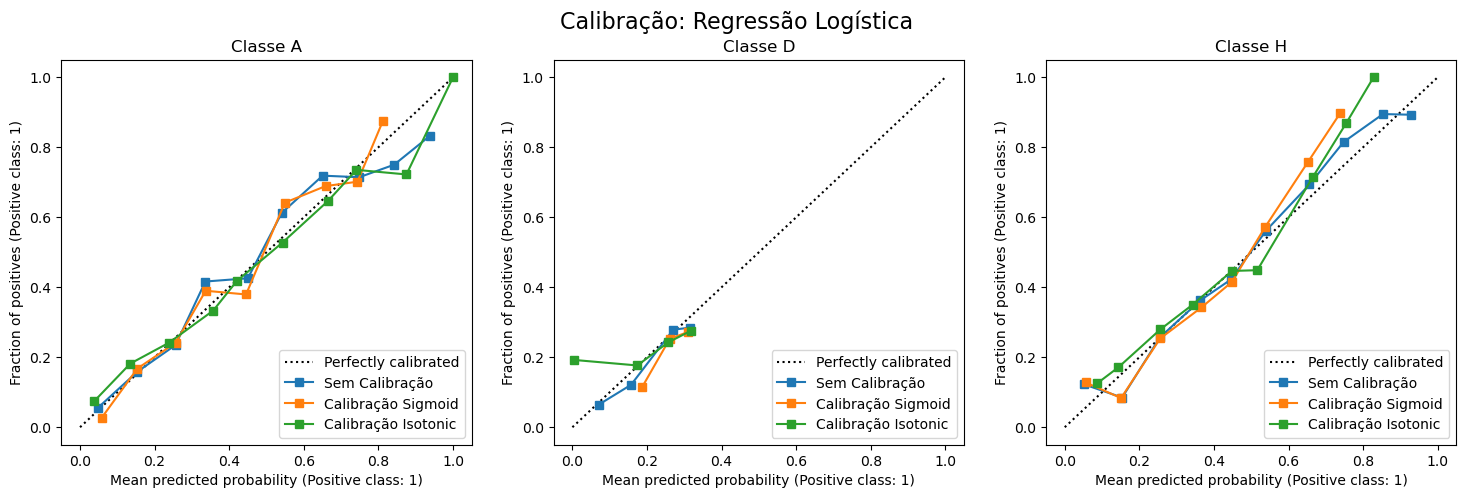


Conclusão: A configuração 'Sem Calibração' gerou o maior lucro real.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

def analyze_calibration_and_utility(model_name, base_model, X_train, y_train, X_cal, y_cal, X_test, y_test, df_test_original, n_bins=10):
    """
    Realiza a análise de calibração completa e avalia a utilidade financeira (lucro) 
    de cada configuração para responder: "Um modelo bem calibrado supera um mal calibrado?"
    """
    global_results = []
    probs_dict = {} 
    classes = np.unique(y_train) 
    y_test_dummies = pd.get_dummies(y_test).values
    
    # Configurações de calibração
    configs = [
        ('Sem Calibração', base_model),
        ('Calibração Sigmoid', CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='sigmoid')),
        ('Calibração Isotonic', CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='isotonic'))
    ]
    
    # 1. Treino do modelo base
    base_model.fit(X_train, y_train)
    
    # 2. Avaliação de Calibração e Utilidade
    for config_name, model in configs:
        if config_name != 'Sem Calibração':
            model.fit(X_cal_scaled, y_cal) 
            
        y_prob = model.predict_proba(X_test_scaled)
        y_pred = model.predict(X_test_scaled)
        probs_dict[config_name] = y_prob
        
        # --- Parte A: Métricas de Calibração ---
        global_brier = np.mean(np.sum((y_test_dummies - y_prob)**2, axis=1))
        ece = calculate_ece_multiclass(y_test, y_prob, classes, n_bins)
        
        # --- Parte B: Avaliação de Utilidade (Financeira) ---
        # df_test_original deve conter 'h_odds', 'd_odds', 'a_odds' e 'result'
        util_res = avaliar_utilidade_calibrada(y_prob, y_test, df_test_original)
        
        global_results.append({
            'Configuração': config_name,
            'Log Loss': log_loss(y_test, y_prob),
            'Brier Score': global_brier,
            'ECE': ece,
            'Acurácia': accuracy_score(y_test, y_pred),
            'Qtd Value Bets': util_res['qtd_value_bets'],
            'Lucro Total (un)': util_res['lucro_total_acumulado'],
            'ROI (%)': (util_res['lucro_total_acumulado'] / util_res['qtd_value_bets']) * 100 if util_res['qtd_value_bets'] > 0 else 0
        })

    # ---------------------------------------------------------
    # Apresentação dos Resultados
    # ---------------------------------------------------------
    df_comparison = pd.DataFrame(global_results).set_index('Configuração')
    print(f"\n=== Comparação de Calibração e Utilidade: {model_name} ===")
    print(df_comparison.round(4).to_string())
    
    # ---------------------------------------------------------
    # Visualização (Gráficos de Calibração)
    # ---------------------------------------------------------
    plot_calibration_curves(model_name, probs_dict, y_test, classes, n_bins)
    
    # Identificar a melhor configuração por lucro real
    best_profit_config = df_comparison['Lucro Total (un)'].idxmax()
    print(f"\nConclusão: A configuração '{best_profit_config}' gerou o maior lucro real.")
    
    return df_comparison

def avaliar_utilidade_calibrada(y_prob, y_test, df_original):
    """Aplica a lógica de Valor Esperado (EV) às probabilidades fornecidas."""
    util_df = df_original[['h_odds', 'd_odds', 'a_odds', 'result']].copy()
    
    # Mapeamento: 0=A, 1=D, 2=H
    util_df['ev_A'] = (y_prob[:, 0] * util_df['a_odds']) - 1
    util_df['ev_D'] = (y_prob[:, 1] * util_df['d_odds']) - 1
    util_df['ev_H'] = (y_prob[:, 2] * util_df['h_odds']) - 1
    
    util_df['max_ev'] = util_df[['ev_H', 'ev_D', 'ev_A']].max(axis=1)
    util_df['sugestao'] = util_df[['ev_H', 'ev_D', 'ev_A']].idxmax(axis=1).str.replace('ev_', '')
    
    # Apostas de Valor (Discordância significativa onde EV > 0)
    value_bets = util_df[util_df['max_ev'] > 0].copy()
    
    def calc_profit(row):
        if row['sugestao'] == row['result']:
            return row[row['sugestao'].lower() + '_odds'] - 1
        return -1
    
    value_bets['lucro'] = value_bets.apply(calc_profit, axis=1)
    
    return {
        'qtd_value_bets': len(value_bets),
        'lucro_total_acumulado': value_bets['lucro'].sum()
    }

def plot_calibration_curves(model_name, probs_dict, y_test, classes, n_bins):
    """Gera gráficos de calibração por classe."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for idx, class_label in enumerate(classes):
        ax = axes[idx]
        y_test_bin = (y_test == class_label).astype(int)
        for config_name, prob_matrix in probs_dict.items():
            CalibrationDisplay.from_predictions(
                y_test_bin, prob_matrix[:, idx], n_bins=n_bins, name=config_name, ax=ax
            )
        ax.set_title(f'Classe {class_label}')
    plt.suptitle(f'Calibração: {model_name}', fontsize=16)
    plt.show()


# 1. Defina o modelo base (ex: sua melhor Regressão Logística)
modelo_base = best_logreg 

# 2. Prepare o DataFrame de suporte para a utilidade
# É crucial que df.loc[y_test.index] contenha as odds: 'h_odds', 'd_odds', 'a_odds'
df_odds_teste = df.loc[y_test.index]

# 3. Chame a função integrada
resultados_finais = analyze_calibration_and_utility(
    model_name="Regressão Logística",
    base_model=modelo_base,
    X_train=X_train_scaled,
    y_train=y_train,
    X_cal=X_cal_scaled,
    y_cal=y_cal,
    X_test=X_test_scaled,
    y_test=y_test,
    df_test_original=df_odds_teste,
    n_bins=10
)

In [ ]:
import pandas as pd
import numpy as np

def prever_aposta_lucrativa(modelo, scaler, novos_dados, odds_jogo):
    """
    modelo: O teu best_logreg treinado.
    scaler: O StandardScaler usado no treino.
    novos_dados: Array/Lista com as features (ht_form_points, ht_form_goals, etc).
    odds_jogo: Dicionário ou Lista com as odds {'H': 2.10, 'D': 3.40, 'A': 3.50}
    """
    # 1. Preparar os dados (padronização)
    dados_reshapeed = np.array(novos_dados).reshape(1, -1)
    dados_scaled = scaler.transform(dados_reshapeed)
    
    # 2. Obter probabilidades do modelo
    # Ordem das classes no Sklearn: [A, D, H]
    probs = modelo.predict_proba(dados_scaled)[0]
    prob_A, prob_D, prob_H = probs[0], probs[1], probs[2]
    
    # 3. Calcular o Valor Esperado (EV) para cada cenário
    # Fórmula: (Probabilidade * Odd) - 1
    ev_h = (prob_H * odds_jogo['H']) - 1
    ev_d = (prob_D * odds_jogo['D']) - 1
    ev_a = (prob_A * odds_jogo['A']) - 1
    
    # 4. Exibir análise detalhada conforme o exemplo solicitado
    print(f"--- Análise de Valor Esperado (EV) ---")
    print(f"Probabilidades do Modelo: H: {prob_H:.2f} | D: {prob_D:.2f} | A: {prob_A:.2f}")
    print(f"Odds da Casa:            H: {odds_jogo['H']:.2f} | D: {odds_jogo['D']:.2f} | A: {odds_jogo['A']:.2f}")
    print("-" * 40)
    print(f"EV(Home) = {prob_H:.2f} * {odds_jogo['H']:.2f} - 1 = {ev_h:+.3f} {'[✓ Profitable]' if ev_h > 0 else '[X No Value]'}")
    print(f"EV(Draw) = {prob_D:.2f} * {odds_jogo['D']:.2f} - 1 = {ev_d:+.3f} {'[✓ Profitable]' if ev_d > 0 else '[X No Value]'}")
    print(f"EV(Away) = {prob_A:.2f} * {odds_jogo['A']:.2f} - 1 = {ev_a:+.3f} {'[✓ Profitable]' if ev_a > 0 else '[X No Value]'}")
    
    # 5. Tomada de Decisão baseada na Máxima Utilidade Esperada
    opcoes = {'Home': ev_h, 'Draw': ev_d, 'Away': ev_a}
    decisao = max(opcoes, key=opcoes.get)
    
    if opcoes[decisao] > 0:
        print(f"\nDecision: Bet on {decisao} - the outcome with positive EV.")
    else:
        print(f"\nDecision: No Bet - No positive EV identified.")

In [ ]:
jogo_teste = [
    2.10,  # h_odds: Odd para vitória em casa
    3.25,  # d_odds: Odd para empate
    3.50,  # a_odds: Odd para vitória fora
    12,    # ht_form_points: 12 pontos nos últimos 5 jogos (Casa)
    10,    # ht_form_goals_scored: 10 golos marcados
    4,     # ht_form_goals_conceded: 4 golos sofridos
    4,     # ht_form_wins: 4 vitórias
    7,     # at_form_points: 7 pontos nos últimos 5 jogos (Fora)
    6,     # at_form_goals_scored: 6 golos marcados
    8,     # at_form_goals_conceded: 8 golos sofridos
    2,     # at_form_wins: 2 vitórias
    9,     # ht_home_form_points: Pontos ganhos em casa
    8,     # ht_home_form_goals_scored: Golos marcados em casa
    4,     # at_away_form_points: Pontos ganhos fora
    3,     # at_away_form_goals_scored: Golos marcados fora
    3,     # h2h_home_wins: Vitórias históricas em casa
    2,     # h2h_draws: Empates históricos
    1      # h2h_away_wins: Vitórias históricas fora
]

colunas = scaler.feature_names_in_
df_jogo_teste = pd.DataFrame([jogo_teste], columns=colunas)
odds_exemplo = {'H': 2.10, 'D': 3.40, 'A': 3.50}
prever_aposta_lucrativa(best_logreg, scaler, df_jogo_teste, odds_exemplo)

--- Análise de Valor Esperado (EV) ---
Probabilidades do Modelo: H: 0.46 | D: 0.29 | A: 0.25
Odds da Casa:            H: 2.10 | D: 3.40 | A: 3.50
----------------------------------------
EV(Home) = 0.46 * 2.10 - 1 = -0.033 [X No Value]
EV(Draw) = 0.29 * 3.40 - 1 = -0.014 [X No Value]
EV(Away) = 0.25 * 3.50 - 1 = -0.127 [X No Value]

Decision: No Bet - No positive EV identified.


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Cenário: Casa em forma "Excecional" vs Fora em forma "Pobre"
jogo_valor = [
    2.10,  # h_odds: Odd alta para um favorito tão forte
    3.40,  # d_odds
    3.50,  # a_odds
    15,    # ht_form_points: 5 vitórias em 5 jogos (Máximo)
    15,    # ht_form_goals_scored: Média de 3 golos por jogo
    2,     # ht_form_goals_conceded: Defesa sólida
    5,     # ht_form_wins: 100% de vitórias
    1,     # at_form_points: Apenas 1 empate nos últimos 5 jogos (Fora)
    2,     # at_form_goals_scored: Ataque inoperante
    12,    # at_form_goals_conceded: Defesa frágil
    0,     # at_form_wins: Nenhuma vitória recente
    15,    # ht_home_form_points: Domínio total em casa
    12,    # ht_home_form_goals_scored
    0,     # at_away_form_points: Não ganha pontos fora
    1,     # at_away_form_goals_scored
    10,    # h2h_home_wins: Histórico esmagador a favor da casa
    2,     # h2h_draws
    0      # h2h_away_wins
]

# Preparar o DataFrame
df_valor = pd.DataFrame([jogo_valor], columns=scaler.feature_names_in_)

# Executar a previsão
odds_exemplo = {'H': 2.10, 'D': 3.40, 'A': 3.50}
prever_aposta_lucrativa(best_logreg, scaler, df_valor, odds_exemplo)

--- Análise de Valor Esperado (EV) ---
Probabilidades do Modelo: H: 0.51 | D: 0.27 | A: 0.21
Odds da Casa:            H: 2.10 | D: 3.40 | A: 3.50
----------------------------------------
EV(Home) = 0.51 * 2.10 - 1 = +0.076 [✓ Profitable]
EV(Draw) = 0.27 * 3.40 - 1 = -0.069 [X No Value]
EV(Away) = 0.21 * 3.50 - 1 = -0.252 [X No Value]

Decision: Bet on Home - the outcome with positive EV.


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### 2. Reject Option e Deferral

Estratégia de deferir para as odds quando o modelo apresenta alta incerteza.

In [ ]:
y_pred = best_logreg.predict(X_test_scaled)
y_proba = best_logreg.predict_proba(X_test_scaled)

baseline_acc = accuracy_score(y_test, y_pred)
print(f"Baseline accuracy (no rejection): {baseline_acc:.4f}")

Baseline accuracy (no rejection): 0.5407


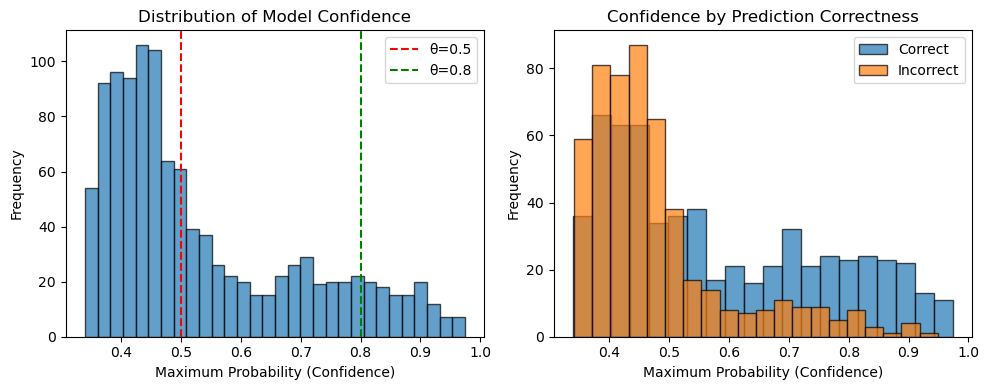

In [ ]:
max_proba = y_proba.max(axis=1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(max_proba, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Maximum Probability (Confidence)')
plt.ylabel('Frequency')
plt.title('Distribution of Model Confidence')
plt.axvline(x=0.5, color='r', linestyle='--', label='θ=0.5')
plt.axvline(x=0.8, color='g', linestyle='--', label='θ=0.8')
plt.legend()

plt.subplot(1, 2, 2)
correct = (y_pred == y_test)
plt.hist(max_proba[correct], bins=20, alpha=0.7, label='Correct', edgecolor='black')
plt.hist(max_proba[~correct], bins=20, alpha=0.7, label='Incorrect', edgecolor='black')
plt.xlabel('Maximum Probability (Confidence)')
plt.ylabel('Frequency')
plt.title('Confidence by Prediction Correctness')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

def reject_predict(clf, X, threshold):
    """
    Realiza previsões com a opção de rejeição baseada em um limiar.
    Retorna 'REJECT' para instâncias onde a confiança é baixa.
    """
    proba = clf.predict_proba(X)
    max_proba = proba.max(axis=1)
    predictions = clf.predict(X)
    
    # Alterado para 'object' para aceitar strings e o marcador de rejeição
    predictions_with_reject = predictions.copy().astype(object)
    
    # Marcador alterado de -1 para 'REJECT' para compatibilidade com strings
    predictions_with_reject[max_proba < threshold] = 'REJECT'
    
    return predictions_with_reject, max_proba

def compute_selective_metrics(y_true, y_pred_with_reject):
    """
    Calcula cobertura e acurácia seletiva para rótulos em string.
    """
    # Verifica contra o novo marcador 'REJECT'
    accepted_mask = y_pred_with_reject != 'REJECT'
    
    coverage = accepted_mask.mean()
    
    if coverage > 0:
        selective_acc = accuracy_score(
            y_true[accepted_mask], 
            y_pred_with_reject[accepted_mask]
        )
    else:
        selective_acc = np.nan
    
    return coverage, selective_acc

# Aplicação
threshold = 0.8
y_pred_reject, _ = reject_predict(best_logreg, X_test_scaled, threshold)
coverage, selective_acc = compute_selective_metrics(y_test, y_pred_reject)

print(f"Threshold: {threshold}")
print(f"Cobertura (Coverage): {coverage:.1%}")
print(f"Acurácia Seletiva: {selective_acc:.4f}")

Threshold: 0.8
Cobertura (Coverage): 10.7%
Acurácia Seletiva: 0.8571


In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin

class ThresholdFallbackClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, threshold=0.5, fallback_label='No Bet'):
        self.estimator = estimator
        self.threshold = threshold
        self.fallback_label = fallback_label

    def fit(self, X, y):
        self.estimator.fit(X, y)
        self.classes_ = self.estimator.classes_
        return self

    def predict(self, X):
        probs = self.estimator.predict_proba(X)
        max_probs = np.max(probs, axis=1)
        base_preds = self.estimator.predict(X)
        
        # Garantimos que o array de saída suporte strings longas
        final_preds = np.where(max_probs >= self.threshold, 
                               base_preds.astype(object), 
                               self.fallback_label)
        return final_preds

# --- Execução com String ---
threshold = 0.8
fb_clf = ThresholdFallbackClassifier(
    estimator=best_logreg, # Teu modelo campeão
    threshold=threshold,
    fallback_label='Reject' # Usamos string para evitar o erro de tipos
)

fb_clf.fit(X_train_scaled, y_train)
y_pred_fb = fb_clf.predict(X_test_scaled)

print(f"Predictions shape: {y_pred_fb.shape}")
print(f"Unique predictions: {np.unique(y_pred_fb)}")
print(f"Number of rejections: {(y_pred_fb == 'Reject').sum()}")

Predictions shape: (1117,)
Unique predictions: ['A' 'H' 'Reject']
Number of rejections: 998


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
accepted_mask = y_pred_fb != -1
selective_acc = accuracy_score(y_test[accepted_mask], y_pred_fb[accepted_mask])

print(f"scikit-fallback Results (threshold={threshold}):")
print(f"  Selective Accuracy: {selective_acc:.4f}")

scikit-fallback Results (threshold=0.8):
  Selective Accuracy: 0.0913


In [ ]:
thresholds = np.linspace(0.1, 0.99, 50)
coverages = []
selective_accs = []
reject_rates = []

for thresh in thresholds:
    y_pred_reject, _ = reject_predict(best_logreg, X_test_scaled, thresh)
    cov, sel_acc = compute_selective_metrics(y_test, y_pred_reject)
    
    coverages.append(cov)
    selective_accs.append(sel_acc)
    reject_rates.append(1 - cov)

coverages = np.array(coverages)
selective_accs = np.array(selective_accs)

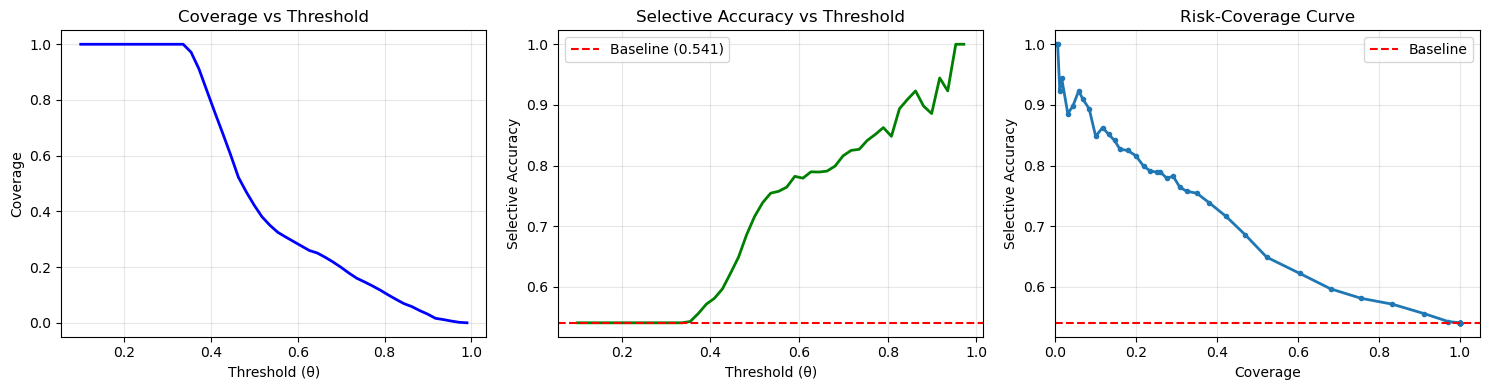

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(thresholds, coverages, 'b-', linewidth=2)
axes[0].set_xlabel('Threshold (θ)')
axes[0].set_ylabel('Coverage')
axes[0].set_title('Coverage vs Threshold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds, selective_accs, 'g-', linewidth=2)
axes[1].axhline(y=baseline_acc, color='r', linestyle='--', label=f'Baseline ({baseline_acc:.3f})')
axes[1].set_xlabel('Threshold (θ)')
axes[1].set_ylabel('Selective Accuracy')
axes[1].set_title('Selective Accuracy vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

valid_mask = ~np.isnan(selective_accs)
axes[2].plot(coverages[valid_mask], selective_accs[valid_mask], 'o-', linewidth=2, markersize=3)
axes[2].axhline(y=baseline_acc, color='r', linestyle='--', label=f'Baseline')
axes[2].set_xlabel('Coverage')
axes[2].set_ylabel('Selective Accuracy')
axes[2].set_title('Risk-Coverage Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0, 1.05])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

def avaliar_desempenho_com_deferral(modelo, X_test_scaled, y_test, df_original, threshold=0.8):
    """
    Implementa Reject Option e Deferral para as Odds.
    Garante que o df de odds use apenas os IDs/índices do teste.
    """
    # 1. Obter probabilidades e confiança da IA
    probs = modelo.predict_proba(X_test_scaled)
    ia_preds = modelo.predict(X_test_scaled)
    confianca_ia = np.max(probs, axis=1) # P(max)
    
    # 2. Alinhar o DataFrame original com os IDs do teste
    # Usamos o .loc[y_test.index] para garantir que as odds batam com os jogos[cite: 4]
    df_teste_odds = df_original.loc[y_test.index].copy()
    
    # 3. Criar estrutura de decisão
    df_decisao = pd.DataFrame({
        'Real': y_test.values,
        'IA_Pred': ia_preds,
        'Confianca': confianca_ia
    }, index=y_test.index)
    
    # Juntar as colunas de odds necessárias
    df_decisao = df_decisao.join(df_teste_odds[['h_odds', 'd_odds', 'a_odds']])
    
    # 4. Lógica de Deferral (Diferimento)
    def decidir_vencedor(row):
        # Se a confiança for alta, a IA decide
        if row['Confianca'] >= threshold:
            return row['IA_Pred']
        
        # Caso contrário, defere para a sabedoria do mercado (favorito das odds)
        # Seleciona a chave (H, D ou A) que possui a menor cotação
        odds_dict = {'H': row['h_odds'], 'D': row['d_odds'], 'A': row['a_odds']}
        return min(odds_dict, key=odds_dict.get)

    df_decisao['Final_Action'] = df_decisao.apply(decidir_vencedor, axis=1)
    
    # 5. Avaliação das métricas de performance seletiva
    mask_ia = df_decisao['Confianca'] >= threshold
    cobertura = mask_ia.mean()
    
    acc_baseline = accuracy_score(y_test, ia_preds)
    acc_seletiva = accuracy_score(y_test[mask_ia], ia_preds[mask_ia]) if any(mask_ia) else 0
    acc_final = accuracy_score(y_test, df_decisao['Final_Action'])
    
    print(f"--- RELATÓRIO DE ESTRATÉGIA (Threshold: {threshold}) ---")
    print(f"Acurácia Baseline (IA sozinha): {acc_baseline:.4f}")
    print(f"Acurácia Seletiva (IA quando está segura): {acc_seletiva:.4f}")
    print(f"Cobertura da IA: {cobertura:.2%}")
    print(f"Taxa de Deferral (Diferido para as Odds): {1 - cobertura:.2%}")
    print("-" * 45)
    print(f"ACURÁCIA FINAL DO SISTEMA HÍBRIDO: {acc_final:.4f}")
    
    return df_decisao

# Exemplo de aplicação:
avaliar_desempenho_com_deferral(best_logreg, X_test_scaled, y_test, df, threshold=0.8)

--- RELATÓRIO DE ESTRATÉGIA (Threshold: 0.8) ---
Acurácia Baseline (IA sozinha): 0.5407
Acurácia Seletiva (IA quando está segura): 0.8571
Cobertura da IA: 10.65%
Taxa de Deferral (Diferido para as Odds): 89.35%
---------------------------------------------
ACURÁCIA FINAL DO SISTEMA HÍBRIDO: 0.5461


,Real,IA_Pred,Confianca,h_odds,d_odds,a_odds,Final_Action
3834,H,A,0.378097,3.10,3.30,2.25,A
5034,H,H,0.957239,1.10,10.00,23.00,H
79,A,H,0.495737,1.80,3.25,4.00,H
167,H,H,0.388255,2.25,3.20,2.80,H
453,A,H,0.491086,1.72,3.30,4.50,H
...,...,...,...,...,...,...,...
2951,H,A,0.692383,6.75,4.00,1.50,A
1562,A,H,0.377432,2.50,3.20,2.88,H
2144,H,H,0.582550,1.57,3.75,6.00,H
1281,A,A,0.393437,3.25,3.20,2.10,A


In [ ]:
avaliar_desempenho_com_deferral(best_logreg, X_test_scaled, y_test, df, threshold=0.5)

--- RELATÓRIO DE ESTRATÉGIA (Threshold: 0.5) ---
Acurácia Baseline (IA sozinha): 0.5407
Acurácia Seletiva (IA quando está segura): 0.7149
Cobertura da IA: 42.08%
Taxa de Deferral (Diferido para as Odds): 57.92%
---------------------------------------------
ACURÁCIA FINAL DO SISTEMA HÍBRIDO: 0.5461


,Real,IA_Pred,Confianca,h_odds,d_odds,a_odds,Final_Action
3834,H,A,0.378097,3.10,3.30,2.25,A
5034,H,H,0.957239,1.10,10.00,23.00,H
79,A,H,0.495737,1.80,3.25,4.00,H
167,H,H,0.388255,2.25,3.20,2.80,H
453,A,H,0.491086,1.72,3.30,4.50,H
...,...,...,...,...,...,...,...
2951,H,A,0.692383,6.75,4.00,1.50,A
1562,A,H,0.377432,2.50,3.20,2.88,H
2144,H,H,0.582550,1.57,3.75,6.00,H
1281,A,A,0.393437,3.25,3.20,2.10,A


In [ ]:
avaliar_desempenho_com_deferral(best_logreg, X_test_scaled, y_test, df, threshold=0.6)

--- RELATÓRIO DE ESTRATÉGIA (Threshold: 0.6) ---
Acurácia Baseline (IA sozinha): 0.5407
Acurácia Seletiva (IA quando está segura): 0.7816
Cobertura da IA: 28.29%
Taxa de Deferral (Diferido para as Odds): 71.71%
---------------------------------------------
ACURÁCIA FINAL DO SISTEMA HÍBRIDO: 0.5461


,Real,IA_Pred,Confianca,h_odds,d_odds,a_odds,Final_Action
3834,H,A,0.378097,3.10,3.30,2.25,A
5034,H,H,0.957239,1.10,10.00,23.00,H
79,A,H,0.495737,1.80,3.25,4.00,H
167,H,H,0.388255,2.25,3.20,2.80,H
453,A,H,0.491086,1.72,3.30,4.50,H
...,...,...,...,...,...,...,...
2951,H,A,0.692383,6.75,4.00,1.50,A
1562,A,H,0.377432,2.50,3.20,2.88,H
2144,H,H,0.582550,1.57,3.75,6.00,H
1281,A,A,0.393437,3.25,3.20,2.10,A
